# Optical design of the BudgetODMR NV setup

## Current setup (original description)
The current optical setup has two perpendicular arms. Since we could not do the fiber coupling, the laser comes off straight from the thorlabs LDM56 laser diode mount and a DJ532-40 laser diode with a small off the shelf chinese colimator we took from a handheld laser pointer. The laser is mounted on a Thorlabs cage system, and then the beam goes through a thorlabs FBW5532-10 filter to clean up the laser light. It is then bounce off a thorlabs DMLP550R mirror and into a N40X-PF objective lens. The beam is then focused onto a high nitrogen density diamond sample. The outcoming fluorescence is collected by the same objective lens and directed back through the DMLP550R mirror. The collected light is then filtered again using a Thorlabs FELH0550 filter to remove any residual laser light. Finally, the filtered light is focused using a Throlabs AC254-150-A-ML lens onto a Thorlabs PDA10A2Si Fixed Gain Detector. Shematically, the light follows the path:

```
DJ532-40 Laser Diode --> Thorlabs FBW5532-10 Filter --> Thorlabs DMLP550R Mirror --> N40X-PF Objective Lens --> Diamond Sample --> N40X-PF Objective Lens --> Thorlabs DMLP550R Mirror --> Thorlabs FELH0550 Filter --> Thorlabs AC254-150-A-ML Lens --> Thorlabs PDA10A2Si Detector
```

Since this is emsemble work for an NV center experiment, the Nikon N40X-PF objective lens is overkill for the current setup. This can be demonstrated by the spot size of the laser on the diamond sample.

## 0. How this notebook models the optics

The notebook compares four configurations using **one shared model** (`optics_model.py` for the physics, `optics_draw.py` for the diagrams, both next to this notebook):

| § | Configuration | Excitation | Collection | Detector |
|---|---|---|---|---|
| 1 | Current | free-space DJ532-40, ~1.4 mm beam | N40X-PF 40×/0.75 | PDA10A2 behind AC254-150 |
| 2 | Fibre-coupled | PM fibre + collimator + polariser + ND | N40X-PF | PDA10A2 behind AC254-150 |
| 3 | Ensemble | ACL25416U-B condenser (f = 16 mm) | same condenser | PDA10A2 behind AC254-150 |
| 4 | Single-NV confocal | N40X-PF (pupil filled) | N40X-PF | pinhole at the AC254-150 focus + PDA10A2 |

Every number is tagged with the model that produced it. **Pick the simplest model that is physically valid for the quantity.** A ray-tracing library was deliberately *not* used: the paraxial matrix tools (e.g. DCC-Lab `RayTracing`) break down exactly where this system is interesting (NA 0.75–0.79 optics, refraction and total internal reflection at an n = 2.42 surface, extended incoherent emitters). Their Gaussian/ABCD part is ~20 lines of numpy, included here.

| Tag | Model | Valid for | Cannot tell you |
|---|---|---|---|
| **[GB]** | Gaussian-beam (complex-q, ABCD) propagation | laser/fibre beams between components; focusing at low NA (≲ 0.2) | anything at high NA, truncation ripples, aberrations |
| **[WO]** | Scalar Debye focusing integral, aplanatic lens, exact air→diamond phase (incl. spherical aberration and the objective's cover-glass correction) | high-NA focal spots, truncated-Gaussian pupil fill, confocal PSFs | polarisation/vectorial effects (FWHM ±5–10 % at NA 0.75), aberrations of the lenses themselves, scattering |
| **[MC]** | Geometric Monte-Carlo ray trace: isotropic emitters in the excited volume, exact Snell + Fresnel + TIR at the diamond surface, ideal sine-condition collection lens, paraxial collimated space with real apertures | collection efficiency, vignetting, spot on the detector, detector-position tolerance for **extended incoherent** sources | diffraction (irrelevant for ensemble spots ≫ λ), the lenses' own aberrations, light scattered or trapped and re-emitted through the diamond edges |
| **[NA]** | Closed-form NA / escape-cone / étendue / magnification estimates | quick bounds and cross-checks for [MC] | anything position-dependent |
| **[DL]** | Diffraction-limited textbook estimates (Airy unit, λ/2NA) | best-case references | real performance when Strehl ≪ 1 |

Units: SI internally; plots use mm/µm/mW as labelled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

import optics_model as om
import optics_draw as od

UM, MM, NM, MW = 1e-6, 1e-3, 1e-9, 1e-3
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 9, "axes.titlesize": 10,
                     "axes.labelsize": 9, "legend.fontsize": 7.5, "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.precision", 3)

PROV = []   # provenance of every input parameter


def param(name, value, unit, source, note="", si=1.0):
    # register a parameter (value in display units) and return it in SI
    PROV.append(dict(parameter=name, value=value, unit=unit, source=source, note=note))
    return value * si if isinstance(value, (int, float)) else value

### 0.1 Component library and where each number comes from

`source` is one of: **datasheet** (manufacturer spec, cited in the project's procurement notes or looked up), **measured** (your lab numbers), **project files** (derived in `procurement/`), **assumed** (a documented modelling choice; change it here), or **UNKNOWN** (needs a measurement; the notebook shows the sensitivity instead of pretending to know it).

In [2]:
# ---- light -------------------------------------------------------------
LAM_EXC = param("Excitation wavelength", 532, "nm", "datasheet", "DJ532-40", NM)
LAM_PL  = param("Representative NV PL wavelength", 700, "nm", "assumed",
                "NV- emission spans ~637-800 nm; one wavelength is used for diffraction estimates", NM)

# ---- laser (configs 1, 3, 4) ------------------------------------------------
D_LASER   = param("Laser beam diameter (1/e2)", 1.4, "mm", "measured (rough)",
                  "viewing card: 'just below 1.5 mm'. Card edge ~ 1/e2 is itself an assumption; +/-0.3 mm", MM)
DIV_LASER = param("Laser full-angle divergence", 0.0, "mrad", "UNKNOWN",
                  "assumed collimated; measure beam diameter at two distances >= 1 m apart", 1e-3)
P_SAMPLE  = param("Excitation power at the sample", 3.0, "mW", "measured (rough)",
                  "'1-5 mW'; measure with the S120C behind the objective", MW)
L_LASER_DICH = param("Laser -> dichroic", 50, "mm", "measured", "", MM)
L_LASER_FBW  = param("Laser -> FBW5532-10", 25, "mm", "assumed", "position irrelevant for a collimated beam", MM)

# ---- filters, dichroic -------------------------------------------------------
FBW_CA    = param("FBW5532-10 clear aperture (dia.)", 10.0, "mm", "assumed", "O12.5 mm mounted filter; CA not found", MM)
FBW_T     = param("FBW5532-10 transmission @532", 0.90, "", "datasheet", ">= 90 %")
FBW_WEDGE = param("FBW5532-10 wedge angle", 30, "arcmin", "datasheet (vendor text, verify)", "wedged filter -> beam deviation",
                  np.pi / 180 / 60)
FBW_N     = param("FBW5532-10 substrate index", 1.46, "", "assumed", "fused silica", 1)
DICH_H, DICH_W = (param("DMLP550R height", 25, "mm", "datasheet", "25 x 36 x 1 mm rectangular", MM),
                  param("DMLP550R width", 36, "mm", "datasheet", "", MM))
DICH_R532 = param("DMLP550R reflectance @532", 0.95, "", "datasheet", ">95 % avg over 380-533 nm; 532 nm is AT the band edge", 1)
DICH_TPL  = param("DMLP550R transmission (PL)", 0.90, "", "datasheet", ">90 % avg 565-800 nm", 1)
FELH_CA   = param("FELH0550 clear aperture (dia.)", 22.0, "mm", "assumed", "O25 mm filter; CA not found", MM)
FELH_T    = param("FELH0550 transmission", 0.90, "", "datasheet", ">90 %, OD>5 at 200-542 nm", 1)

# ---- N40X-PF objective -------------------------------------------------------
OBJ_F, OBJ_NA = param("N40X-PF focal length", 5, "mm", "datasheet", "", MM), param("N40X-PF NA", 0.75, "", "datasheet")
OBJ_WD    = param("N40X-PF working distance", 0.66, "mm", "datasheet", "", MM)
OBJ_PUPIL = param("N40X-PF entrance pupil dia.", 7.5, "mm", "datasheet", "= 2 NA f", MM)
OBJ_TCG   = param("N40X-PF cover-glass correction", 0.17, "mm", "datasheet",
                  "no cover glass is used -> residual spherical aberration; check whether a collar is fitted", MM)
OBJ_PARF  = param("N40X-PF parfocal length", 60, "mm", "datasheet", "pupil placed at the shoulder (assumed)", MM)
OBJ_T     = param("N40X-PF transmission (PL)", 0.80, "", "assumed", "not found; typical Plan Fluor", 1)

# ---- collection train (config 1) -----------------------------------------------
L_OBJ_DICH = param("Objective shoulder -> dichroic centre", 30, "mm", "assumed", "", MM)
L_OBJ_FELH = param("Objective shoulder -> FELH0550", 55, "mm", "assumed", "", MM)
L_OBJ_LENS = param("Objective shoulder -> AC254-150", 85, "mm", "measured", "'8-9 cm'", MM)
AC_F  = param("AC254-150-A focal length", 150, "mm", "datasheet", "", MM)
AC_CA = param("AC254-150-A clear aperture (dia.)", 22.9, "mm", "assumed", "Thorlabs CA > 90 % of O25.4", MM)
L_LENS_DET = param("AC254-150 -> detector", 150, "mm", "measured", "", MM)
DET_AREA = param("PDA10A2 active area", 0.8, "mm2", "datasheet", "O1.0 mm", MM ** 2)
R_DET = np.sqrt(DET_AREA / np.pi)

# ---- diamond --------------------------------------------------------------------
N_D = om.N_DIAMOND
T_DIAM = param("DNVB14 thickness", 0.5, "mm", "datasheet + user", "3.0 x 3.0 x 0.5 mm", MM)
NV_PPM = param("DNVB14 NV concentration", 4.5, "ppm", "datasheet", "", 1)
ALPHA  = param("Absorption coefficient @532", None, "1/cm", "UNKNOWN",
               "set to 0 (uniform column) in [MC]; sensitivity shown in section 3", 100)
I_SAT  = param("NV saturation intensity (order of magnitude)", 1.0, "MW/cm2", "literature scale",
               "published values span roughly 0.1-1 MW/cm2 depending on definition; only used to flag regimes", 1e10)

# ---- ACL25416U-B condenser (config 3) --------------------------------------------
ACL_F, ACL_NA = param("ACL25416U-B EFL", 16, "mm", "datasheet", "", MM), param("ACL25416U-B NA", 0.79, "", "datasheet")
ACL_BFL = param("ACL25416U-B back focal length", 7.3, "mm", "datasheet", "flat face -> focus", MM)
ACL_CT  = param("ACL25416U-B centre thickness", 14, "mm", "datasheet", "B270 glass, conic -0.999", MM)
ACL_R532 = param("ACL25416U-B reflectance per surface @532", 0.05, "", "assumed",
                 "-B coating is specified 650-1050 nm only; check the coating curve", 1)

# ---- fibre-coupled delivery (config 2) --------------------------------------------
MFD     = param("P3-405BPM-FC-1 mode-field dia. @532", 4.0, "um", "project files",
                "interpolated from 3.3 um @405 and 4.6 um @630 - verify", UM)
FIB_ER  = param("PM fibre extinction ratio", 15, "dB", "datasheet", "15 dB min / 17 dB typ", 1)
COLLIMATORS = {   # name: (EFL, NA, source)
    "F240APC-532":  (7.86 * MM, 0.51, "datasheet"),
    "ACL25416U-B":  (16.0 * MM, 0.79, "datasheet"),
    "F810APC-543":  (34.74 * MM, 0.26, "datasheet"),
}
ND_T, ND_N = param("ND filter thickness", 2.0, "mm", "assumed", "NE10A/NE20A glass, ~2 mm", MM), param("ND glass index", 1.52, "", "assumed")
ND_TILT = param("ND filter tilt", 3, "deg", "assumed", "tilted to keep reflections out of the fibre", np.pi / 180)

display(pd.DataFrame(PROV))

,parameter,value,unit,source,note
0,Excitation wavelength,532.00,nm,datasheet,DJ532-40
1,Representative NV PL wavelength,700.00,nm,assumed,NV- emission spans ~637-800 nm; one wavelength...
2,Laser beam diameter (1/e2),1.40,mm,measured (rough),viewing card: 'just below 1.5 mm'. Card edge ~...
3,Laser full-angle divergence,0.00,mrad,UNKNOWN,assumed collimated; measure beam diameter at t...
4,Excitation power at the sample,3.00,mW,measured (rough),'1-5 mW'; measure with the S120C behind the ob...
5,Laser -> dichroic,50.00,mm,measured,
6,Laser -> FBW5532-10,25.00,mm,assumed,position irrelevant for a collimated beam
7,FBW5532-10 clear aperture (dia.),10.00,mm,assumed,O12.5 mm mounted filter; CA not found
8,FBW5532-10 transmission @532,0.90,,datasheet,>= 90 %
9,FBW5532-10 wedge angle,30.00,arcmin,"datasheet (vendor text, verify)",wedged filter -> beam deviation


### 0.2 Shared analysis functions
Used by all four sections so the configurations are compared on identical footing.

In [3]:
def focus_metrics(D_beam, f, NA, lam=LAM_EXC, n2=N_D, t_cg=0.0, depth=0.0, rmax=8 * UM):
    # [WO] focal spot of a Gaussian beam (1/e2 dia. D_beam at the pupil) through lens f / NA,
    # focused `depth` into medium n2, stage re-optimised for the brightest focus
    F = om.Focus(lam, NA, f, D_beam / 2, n2, t_cg=t_cg)
    zf, strehl = F.best_focus(depth)
    r = np.linspace(0, rmax, 2000)
    I = F.intensity(r, depth, zf)[0]
    clip = om.gauss_clip(D_beam / 2, f * NA)
    below = np.where(I / I[0] < np.exp(-2))[0]
    return dict(F=F, zf=zf, strehl=strehl, fwhm=om.radial_fwhm(r, I),
                w_e2=r[below[0]] if len(below) else np.nan,
                I_per_W=I[0] / F.total * clip,      # peak intensity per watt arriving at the pupil
                pupil_transmission=clip, r=r, I=I)


def collection_stops(L_dich, L_felh, L_lens):
    # apertures in the collimated space, measured from the collection lens pupil
    # dichroic at 45 deg: 25 mm tall, 36 mm long -> 25.5 mm projected width
    return [(L_dich, ("rect", DICH_W * np.cos(np.pi / 4) / 2, DICH_H / 2)),
            (L_felh, ("circle", FELH_CA / 2)),
            (L_lens, ("circle", AC_CA / 2))]


def run_mc(w_in, f_exc, focus_depth, f_coll, NA_coll, stops, L2, f2=AC_F, d2=None, det_r=R_DET,
           alpha=0.0, n=600_000, seed=1):
    # [MC] emitters along the (paraxial Gaussian) excitation column, traced to the detector
    em = om.sample_gaussian_column(n, lambda z: om.beam_in_diamond(w_in, f_exc, LAM_EXC, focus_depth, z),
                                   T_DIAM, alpha, rng=seed)
    res = om.mc_collect(em, f=f_coll, NA=NA_coll, z_f=focus_depth / N_D, stops=stops, f2=f2, L2=L2,
                        d2=f2 if d2 is None else d2, det=("circle", det_r), rng=seed + 1, return_rays=True)
    return res


def detector_scan(res, L2, f2, offsets_ax, offsets_lat, det_r=R_DET):
    # re-use traced rays: detector moved along the axis / sideways
    R = res["rays"]
    w = R["T"] * R["pre"]
    X2, Y2 = R["px"] + R["ax"] * L2, R["py"] + R["ay"] * L2
    bx, by = R["ax"] - X2 / f2, R["ay"] - Y2 / f2
    ax_curve = [np.sum(w * (np.hypot(X2 + bx * (f2 + d), Y2 + by * (f2 + d)) <= det_r)) for d in offsets_ax]
    Xd, Yd = X2 + bx * f2, Y2 + by * f2
    lat_curve = [np.sum(w * (np.hypot(Xd - d, Yd) <= det_r)) for d in offsets_lat]
    norm = np.sum(w)
    return np.array(ax_curve) / norm, np.array(lat_curve) / norm


def stage_table(results):
    # results: {config label: mc result}; fractions of ALL emitted PL (4 pi)
    keys = ["escape (no TIR)", "within lens NA", "through filters/dichroic/lens stops", "on detector"]
    return pd.DataFrame({lab: {k: 100 * r[k] for k in keys} for lab, r in results.items()}).rename(
        index=lambda k: k + " (% of 4pi)")


def pl_beam_sizes(res, planes):
    # radius containing 95 % / 100 % of the PL rays that make it through the lens NA
    R = res["rays"]
    m = R["in_na"]
    out = []
    for name, L in planes:
        rr = np.hypot(R["px"][m] + R["ax"][m] * L, R["py"][m] + R["ay"][m] * L)
        out.append({"plane": name, "distance from pupil (mm)": L / MM,
                    "PL beam dia. 95% (mm)": 2 * np.percentile(rr, 95) / MM, "PL beam dia. max (mm)": 2 * rr.max() / MM})
    return pd.DataFrame(out).set_index("plane")

---
## 1. Current setup: free-space laser, N40X-PF for excitation and collection

**Excitation path:** DJ532-40 → FBW5532-10 (532/10 bandpass) → DMLP550R (reflects 532 nm) → N40X-PF → DNVB14.
**Collection path:** DNVB14 → N40X-PF → DMLP550R (transmits > 565 nm) → FELH0550 → AC254-150-A → PDA10A2 at its focus.

Models used: **[GB]** for the laser beam up to the objective pupil and the (low-NA, see below) focus; **[WO]** to check that the Gaussian formula is valid and to answer the pupil-fill question; **[NA]** and **[MC]** for collection.

In [4]:
# ---- configuration 1 geometry (mm are converted to SI) -------------------------
W_LASER = D_LASER / 2
FOCUS_DEPTH_1 = param("Config 1: excitation focus depth in diamond", 100, "um", "assumed",
                      "where you focus is not recorded; section 1.4 scans it", UM)
arm1 = [("space", L_LASER_FBW, 1.0), ("aperture", FBW_CA / 2, "FBW5532-10"),
        ("space", L_LASER_DICH - L_LASER_FBW, 1.0), ("aperture", DICH_H / 2, "DMLP550R"),
        ("space", L_OBJ_DICH, 1.0), ("aperture", OBJ_PUPIL / 2, "N40X-PF pupil")]
z1, w1, tab1, q_pupil = om.trace_gaussian(W_LASER, LAM_EXC, arm1)
display(Markdown("**[GB] Excitation beam from the laser to the objective pupil** (waist assumed at the laser; "
                 f"Rayleigh range $\\pi w^2/\\lambda$ = {np.pi * W_LASER**2 / LAM_EXC:.1f} m, so the beam barely changes over 8 cm)"))
display(pd.DataFrame([{"element": t["name"], "path from laser (mm)": t["z"] / MM, "beam dia. 1/e2 (mm)": 2 * t["w"] / MM,
                       "fraction clipped": t["clip"]} for t in tab1]).set_index("element"))

# divergence sensitivity: a non-collimated beam moves the focus (Newton: dz = f^2 / R)
for div in [0.5e-3, 1e-3, 2e-3]:
    R_curv = W_LASER / (div / 2)
    print(f"if the full divergence were {div*1e3:.1f} mrad: focus shift ~ f^2/R = {OBJ_F**2 / R_curv / UM:5.1f} um in air "
          f"(~{N_D * OBJ_F**2 / R_curv / UM:.0f} um in diamond, paraxial), beam at pupil {2*(W_LASER + div/2*0.08)/MM:.2f} mm")

**[GB] Excitation beam from the laser to the objective pupil** (waist assumed at the laser; Rayleigh range $\pi w^2/\lambda$ = 2.9 m, so the beam barely changes over 8 cm)

,path from laser (mm),beam dia. 1/e2 (mm),fraction clipped
element,,,
FBW5532-10,25.0,1.400,0.0
DMLP550R,50.0,1.400,0.0
N40X-PF pupil,80.0,1.401,0.0


if the full divergence were 0.5 mrad: focus shift ~ f^2/R =   8.9 um in air (~22 um in diamond, paraxial), beam at pupil 1.44 mm
if the full divergence were 1.0 mrad: focus shift ~ f^2/R =  17.9 um in air (~43 um in diamond, paraxial), beam at pupil 1.48 mm
if the full divergence were 2.0 mrad: focus shift ~ f^2/R =  35.7 um in air (~86 um in diamond, paraxial), beam at pupil 1.56 mm


### 1.1 Focal spot and the pupil-fill question

The objective's entrance pupil is 2·NA·f = 7.5 mm, and the laser beam is ~1.4 mm. The beam is **under-filling** the pupil, so the objective behaves like a lens of *effective* NA ≈ w/f ≈ 0.14, not 0.75. The plot below computes the focal spot **[WO]** for any beam diameter at the pupil. It answers the question about over-filling:

* **Under-filled** (your case): Gaussian spot, $w_0 = \lambda f/(\pi w)$, no rings, all power transmitted. The spot is ~5× larger than the objective can make.
* **Filled** (beam ≈ pupil): smallest useful spot. The truncated Gaussian throws a few % of the power away and has very weak rings.
* **Over-filled** (beam ≫ pupil): the pupil becomes uniformly lit, the spot tends to the Airy pattern (first ring 1.75 % of the peak) and **most of the power is lost on the pupil edge**. Over-filling does not make the spot "bad". The Airy pattern *is* the diffraction limit. It wastes power and adds rings, and the spot stops shrinking once D ≳ pupil.

The usual compromise is D(1/e²) ≈ 0.9–1× the pupil diameter.

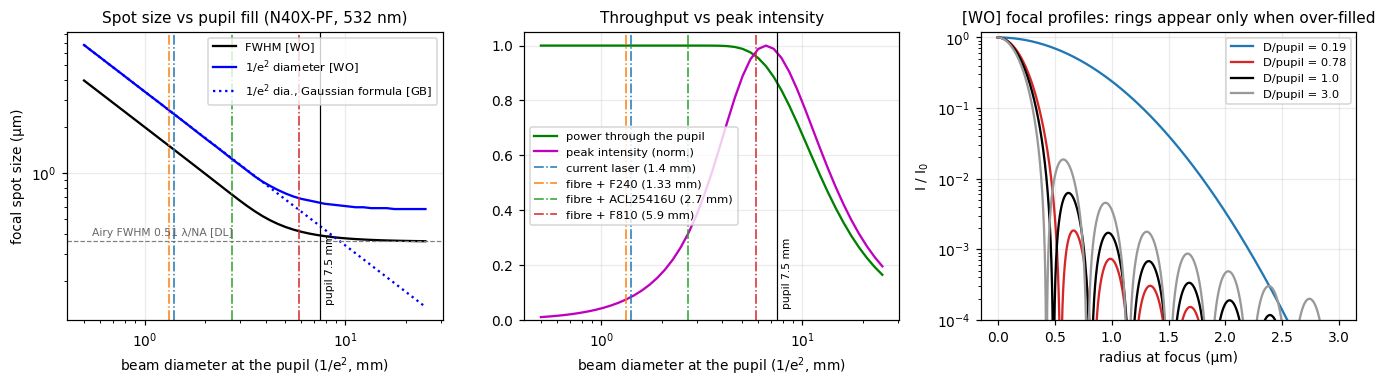

In [5]:
D_scan = np.geomspace(0.5, 25, 45) * MM
scan = [focus_metrics(D, OBJ_F, OBJ_NA, n2=1.0) for D in D_scan]       # ideal: air sample, no aberration
fw = np.array([s["fwhm"] for s in scan]); we2 = np.array([s["w_e2"] for s in scan])
Ipk = np.array([s["I_per_W"] for s in scan]); Tp = np.array([s["pupil_transmission"] for s in scan])
w_gauss = LAM_EXC * OBJ_F / (np.pi * D_scan / 2)

marks = {"current laser (1.4 mm)": D_LASER,
         "fibre + F240 (1.33 mm)": om.collimated_diameter(MFD, LAM_EXC, 7.86 * MM),
         "fibre + ACL25416U (2.7 mm)": om.collimated_diameter(MFD, LAM_EXC, 16 * MM),
         "fibre + F810 (5.9 mm)": om.collimated_diameter(MFD, LAM_EXC, 34.74 * MM)}

fig, axs = plt.subplots(1, 3, figsize=(12.5, 3.6))
ax = axs[0]
ax.loglog(D_scan / MM, fw / UM, "k-", label="FWHM [WO]")
ax.loglog(D_scan / MM, 2 * we2 / UM, "b-", label="1/e$^2$ diameter [WO]")
ax.loglog(D_scan / MM, 2 * w_gauss / UM, "b:", label="1/e$^2$ dia., Gaussian formula [GB]")
ax.axhline(0.51 * LAM_EXC / OBJ_NA / UM, color="0.5", ls="--", lw=0.8)
ax.text(0.55, 0.51 * LAM_EXC / OBJ_NA / UM * 1.08, "Airy FWHM 0.51 λ/NA [DL]", fontsize=7, color="0.4")
ax.set_xlabel("beam diameter at the pupil (1/e$^2$, mm)"); ax.set_ylabel("focal spot size (µm)")
ax.set_title("Spot size vs pupil fill (N40X-PF, 532 nm)")
ax2 = axs[1]
ax2.semilogx(D_scan / MM, Tp, "g-", label="power through the pupil")
ax2.semilogx(D_scan / MM, Ipk / Ipk.max(), "m-", label="peak intensity (norm.)")
ax2.set_xlabel("beam diameter at the pupil (1/e$^2$, mm)"); ax2.set_ylim(0, 1.05)
ax2.set_title("Throughput vs peak intensity")
for a in axs[:2]:
    a.axvline(OBJ_PUPIL / MM, color="k", lw=0.8); a.text(OBJ_PUPIL / MM * 1.05, a.get_ylim()[0] * 1.3 if a is ax else 0.05,
                                                          "pupil 7.5 mm", fontsize=7, rotation=90)
    for i, (lab, D) in enumerate(marks.items()):
        a.axvline(D / MM, color=f"C{i}", lw=1, ls="-.", label=lab if a is ax2 else None)
    a.legend(loc="best")
ax3 = axs[2]
r = np.linspace(0, 3, 1500) * UM
for ratio, c in [(0.19, "C0"), (0.78, "C3"), (1.0, "k"), (3.0, "0.6")]:
    F = om.Focus(LAM_EXC, OBJ_NA, OBJ_F, ratio * OBJ_PUPIL / 2, 1.0)
    I = F.intensity(r, 0.0)[0]
    ax3.semilogy(r / UM, I / I[0], color=c, label=f"D/pupil = {ratio}")
ax3.set_ylim(1e-4, 1.2); ax3.set_xlabel("radius at focus (µm)"); ax3.set_ylabel("I / I$_0$")
ax3.set_title("[WO] focal profiles: rings appear only when over-filled"); ax3.legend()
plt.tight_layout(); plt.show()

In [6]:
# [WO] config 1 focal spot inside the diamond (objective corrected for 0.17 mm cover glass, none present)
f1_surface = focus_metrics(D_LASER, OBJ_F, OBJ_NA, n2=N_D, t_cg=OBJ_TCG, depth=5 * UM)
f1_depth = focus_metrics(D_LASER, OBJ_F, OBJ_NA, n2=N_D, t_cg=OBJ_TCG, depth=FOCUS_DEPTH_1)
g1 = om.gaussian_focus(W_LASER, OBJ_F, LAM_EXC, N_D)
I_pk = 2 * P_SAMPLE / (np.pi * g1["w0"] ** 2)
display(pd.DataFrame({
    "value": [g1["NA_eff"], 2 * g1["w0"] / UM, f1_depth["fwhm"] / UM, 2 * f1_depth["w_e2"] / UM, g1["zR"] / UM,
              np.degrees(g1["theta"]), f1_depth["strehl"], I_pk / 1e10, I_pk / I_SAT],
    "model": ["[GB] w/f", "[GB]", "[WO]", "[WO]", "[GB] n pi w0^2/lambda", "[GB]", "[WO]", "[GB]", "[GB] vs literature scale"]},
    index=["effective excitation NA (in air)", "spot 1/e2 diameter (um)", "spot FWHM at 100 um depth (um)",
           "spot 1/e2 diameter at 100 um depth (um)", "Rayleigh range inside diamond (um)",
           "far-field half-angle inside diamond (deg)", "Strehl ratio at 100 um depth",
           f"peak intensity at {P_SAMPLE/MW:.0f} mW (MW/cm2)", "peak intensity / I_sat (order of magnitude)"]))
print(f"Gaussian formula vs full wave model at 100 um depth: {2*g1['w0']/UM:.2f} vs {2*f1_depth['w_e2']/UM:.2f} um "
      "-> at NA_eff 0.14 the paraxial Gaussian model is adequate, and aberrations are negligible")

,value,model
effective excitation NA (in air),0.140,[GB] w/f
spot 1/e2 diameter (um),2.419,[GB]
spot FWHM at 100 um depth (um),1.422,[WO]
spot 1/e2 diameter at 100 um depth (um),2.417,[WO]
Rayleigh range inside diamond (um),20.908,[GB] n pi w0^2/lambda
far-field half-angle inside diamond (deg),3.315,[GB]
Strehl ratio at 100 um depth,0.999,[WO]
peak intensity at 3 mW (MW/cm2),0.131,[GB]
peak intensity / I_sat (order of magnitude),0.131,[GB] vs literature scale


Gaussian formula vs full wave model at 100 um depth: 2.42 vs 2.42 um -> at NA_eff 0.14 the paraxial Gaussian model is adequate, and aberrations are negligible


### 1.2 Collection: what the objective can see

**[NA] The diamond sets the limit before any lens does.** Light from inside n = 2.42 escapes a flat face only within the critical angle, 24.4°. Every ray inside that cone reaches the air side at some angle up to 90°, so even a hypothetical NA = 1 lens collects at most ~3.5 % of the emission (after Fresnel loss). NA 0.75 captures the cone out to 18.1° inside the diamond.

**Assumptions about the emission.** The ensemble contains all four NV orientations with random (unpolarised) dipoles, so the emission is treated as **isotropic** and unpolarised (Fresnel losses averaged over s and p). Emission into the lower hemisphere, reflection off the back face and light guided out through the side faces are **not counted**. The collected fractions are therefore lower bounds, most relevant to the *relative* comparisons.

In [7]:
rows = []
for lab, NA in [("N40X-PF (0.75)", 0.75), ("ACL25416U-B (0.79)", 0.79), ("hypothetical NA 1.0", 1.0)]:
    rows.append({"lens": lab, "half-angle inside diamond (deg)": np.degrees(np.arcsin(min(NA, 1) / N_D)),
                 "fraction of 4pi, no Fresnel (%)": 100 * om.escape_cone_fraction(NA),
                 "fraction of 4pi, with Fresnel (%)": 100 * om.escape_cone_fraction_fresnel(NA)})
display(pd.DataFrame(rows).set_index("lens"))

,half-angle inside diamond (deg),"fraction of 4pi, no Fresnel (%)","fraction of 4pi, with Fresnel (%)"
lens,,,
N40X-PF (0.75),18.054,2.462,2.029
ACL25416U-B (0.79),19.053,2.739,2.254
hypothetical NA 1.0,24.407,4.469,3.512


### 1.3 [MC] Where the collected light goes: the PDA10A2 is acting as a pinhole

The detector sits at the focus of the AC254-150, so it sees an **image** of the sample. The lateral magnification is f_AC/f_obj = 150/5 = 30, so the Ø1 mm PDA10A2 back-projects to a Ø34 µm disc in the sample. The excitation beam, however, lights up a **0.5 mm long column** through the whole diamond thickness. The longitudinal magnification (~M² = 900) puts the images of most of that column far out of focus at the detector plane. The Monte-Carlo trace quantifies how much light survives each stage.

In [8]:
X_PUP1 = OBJ_PARF        # collimated-space origin: objective shoulder (pupil ~ at the shoulder, assumed)
stops1 = collection_stops(L_OBJ_DICH, L_OBJ_FELH, L_OBJ_LENS)
mc1 = run_mc(W_LASER, OBJ_F, FOCUS_DEPTH_1, OBJ_F, OBJ_NA, stops1, L_OBJ_LENS)
mc1_f50 = run_mc(W_LASER, OBJ_F, FOCUS_DEPTH_1, OBJ_F, OBJ_NA, stops1, L_OBJ_LENS, f2=50 * MM)
display(stage_table({"config 1 (as built)": mc1, "config 1 with f=50 mm detector lens (what-if)": mc1_f50}))
display(pl_beam_sizes(mc1, [("DMLP550R", L_OBJ_DICH), ("FELH0550", L_OBJ_FELH), ("AC254-150", L_OBJ_LENS)]))
print(f"[NA] detector back-projected into the sample: radius {R_DET * OBJ_F / AC_F / UM:.1f} um "
      f"(f=50 mm lens: {R_DET * OBJ_F / (50*MM) / UM:.0f} um)")
print(f"[NA] cone of light converging on the detector: NA = {OBJ_F*OBJ_NA/AC_F:.3f} -> no angular problem for a bare photodiode")

depth_sweep = np.array([10, 30, 60, 100, 150, 200, 300, 400]) * UM
sweep1 = [100 * run_mc(W_LASER, OBJ_F, d, OBJ_F, OBJ_NA, stops1, L_OBJ_LENS, n=400_000)["on detector"] for d in depth_sweep]
print("\nfocus depth (um)       :", "  ".join(f"{d/UM:5.0f}" for d in depth_sweep))
print("PL on detector (% 4pi) :", "  ".join(f"{s:5.2f}" for s in sweep1))

,config 1 (as built),config 1 with f=50 mm detector lens (what-if)
escape (no TIR) (% of 4pi),3.518,3.518
within lens NA (% of 4pi),2.026,2.026
through filters/dichroic/lens stops (% of 4pi),2.026,2.026
on detector (% of 4pi),0.705,1.494


,distance from pupil (mm),PL beam dia. 95% (mm),PL beam dia. max (mm)
plane,,,
DMLP550R,30.0,7.158,8.055
FELH0550,55.0,7.238,8.524
AC254-150,85.0,7.410,9.086


[NA] detector back-projected into the sample: radius 16.8 um (f=50 mm lens: 50 um)
[NA] cone of light converging on the detector: NA = 0.025 -> no angular problem for a bare photodiode



focus depth (um)       :    10     30     60    100    150    200    300    400
PL on detector (% 4pi) :  0.45   0.55   0.65   0.72   0.74   0.76   0.76   0.52


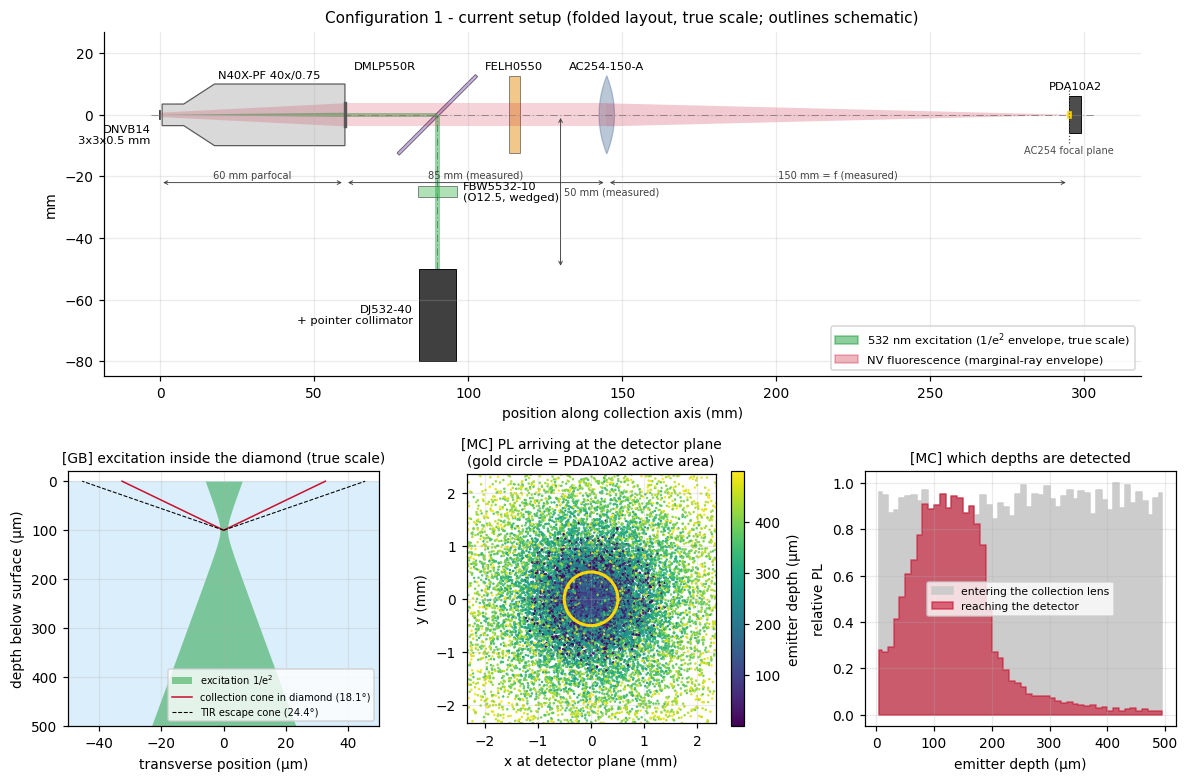

In [9]:
# ---- figure: configuration 1 ------------------------------------------------------
def layout_dict(optic, x_front, x_pupil, pupil_r, L_dich, L_felh, L_lens, d_det, w_pupil, r_pl, NA_coll,
                arm, y_source, source, exc_w_of_y, x_pinhole=None, r_pinhole=None, r_after=None):
    y = np.linspace(y_source / MM, 0, 200)
    S = dict(optic=optic, x_optic_front=x_front / MM, x_pupil=x_pupil / MM, pupil_r=pupil_r / MM,
             x_dich=(x_pupil + L_dich) / MM, x_felh=(x_pupil + L_felh) / MM, x_lens=(x_pupil + L_lens) / MM,
             x_det=(x_pupil + L_lens + d_det) / MM, r_det=R_DET / MM, arm=arm, y_source=y_source / MM,
             source=source, exc_y=y, exc_w=exc_w_of_y(y), w_exc_pupil=w_pupil / MM, r_pl=r_pl / MM, NA_coll=NA_coll)
    S["arm"] = [(e[0], e[1] / MM) + tuple(e[2:]) for e in arm]      # arm positions -> mm for drawing
    if x_pinhole is not None:
        S.update(x_pinhole=x_pinhole / MM, r_pinhole=r_pinhole / MM, r_after_pinhole=r_after / MM)
    return S


def config_figure(S, title, zoom, mc, dims):
    fig = plt.figure(figsize=(13, 8.2))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.35, 1], hspace=0.32, wspace=0.28)
    ax = fig.add_subplot(gs[0, :])
    od.draw_system(ax, S)
    for d in dims:
        (od.hdim if d[0] == "h" else od.vdim)(ax, *d[1:])
    ax.legend(handles=od.legend_handles(), loc="lower right", fontsize=7.5)
    ax.set_title(title)
    axz = fig.add_subplot(gs[1, 0])
    od.sample_zoom(axz, **zoom)
    R = mc["rays"]
    axd = fig.add_subplot(gs[1, 1])
    m = R["pre"]
    sel = np.where(m)[0][:25000]
    sc = axd.scatter(R["Xd"][sel] / MM, R["Yd"][sel] / MM, c=R["z"][sel] / UM, s=0.4, cmap="viridis", rasterized=True)
    axd.add_patch(plt.Circle((0, 0), R_DET / MM, fill=False, color="gold", lw=2))
    lim = max(1.5, np.percentile(np.hypot(R["Xd"][sel], R["Yd"][sel]), 90) / MM)
    axd.set_xlim(-lim, lim); axd.set_ylim(-lim, lim); axd.set_aspect("equal")
    plt.colorbar(sc, ax=axd, label="emitter depth (µm)")
    axd.set_xlabel("x at detector plane (mm)"); axd.set_ylabel("y (mm)")
    axd.set_title("[MC] PL arriving at the detector plane\n(gold circle = PDA10A2 active area)", fontsize=9)
    axh = fig.add_subplot(gs[1, 2])
    bins = np.linspace(0, T_DIAM / UM, 51)
    wts = R["T"]
    h_all, _ = np.histogram(R["z"][R["in_na"]] / UM, bins, weights=wts[R["in_na"]])
    h_det, _ = np.histogram(R["z"][R["hit"]] / UM, bins, weights=wts[R["hit"]])
    c = 0.5 * (bins[1:] + bins[:-1])
    axh.fill_between(c, h_all / h_all.max(), step="mid", color="0.8", label="entering the collection lens")
    axh.fill_between(c, h_det / h_all.max(), step="mid", color=od.C_PL, alpha=0.6, label="reaching the detector")
    axh.set_xlabel("emitter depth (µm)"); axh.set_ylabel("relative PL")
    axh.set_title("[MC] which depths are detected", fontsize=9); axh.legend(fontsize=7)
    return fig


arm_1 = [("filter", -(L_LASER_DICH - L_LASER_FBW), "FBW5532-10\n(O12.5, wedged)")]
S1 = layout_dict("objective", OBJ_WD, X_PUP1, OBJ_PUPIL / 2, L_OBJ_DICH, L_OBJ_FELH, L_OBJ_LENS, L_LENS_DET,
                 W_LASER, OBJ_F * OBJ_NA, OBJ_NA, arm_1, -L_LASER_DICH, "laser",
                 lambda y: np.full_like(y, W_LASER / MM))
zd = np.linspace(0, T_DIAM, 300)
zoom1 = dict(z_um=zd / UM, w_um=om.beam_in_diamond(W_LASER, OBJ_F, LAM_EXC, FOCUS_DEPTH_1, zd) / UM, NA_coll=OBJ_NA,
             focus_um=FOCUS_DEPTH_1 / UM, title="[GB] excitation inside the diamond (true scale)")
x_dich = (X_PUP1 + L_OBJ_DICH) / MM
dims1 = [("h", X_PUP1 / MM, (X_PUP1 + L_OBJ_LENS) / MM, -22, "85 mm (measured)"),
         ("h", (X_PUP1 + L_OBJ_LENS) / MM, (X_PUP1 + L_OBJ_LENS + L_LENS_DET) / MM, -22, "150 mm = f (measured)"),
         ("h", 0, X_PUP1 / MM, -22, "60 mm parfocal"),
         ("v", -L_LASER_DICH / MM, 0, x_dich + 40, "50 mm (measured)")]
fig = config_figure(S1, "Configuration 1 - current setup (folded layout, true scale; outlines schematic)", zoom1, mc1, dims1)
od.focal_plane(fig.axes[0], (X_PUP1 + L_OBJ_LENS + L_LENS_DET) / MM - 0.01, 9, "AC254 focal plane")
plt.show()

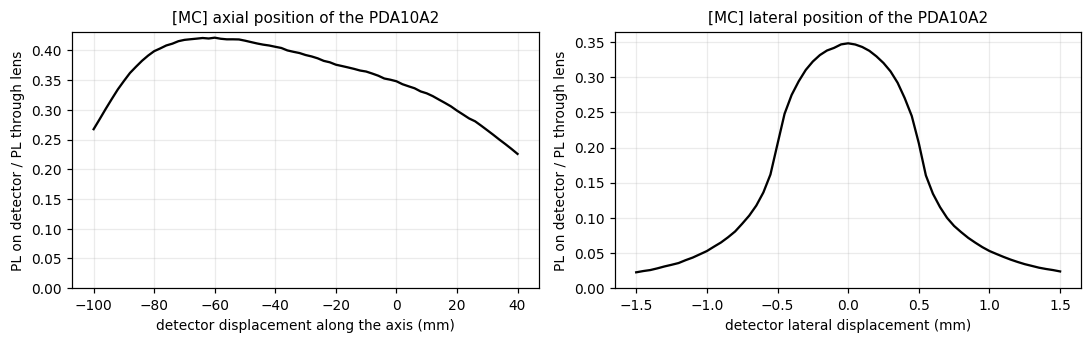

best axial position: -60 mm from the AC254 focal plane (gain x1.21 over the focal plane); within 90% of the focal-plane signal over 108 mm; lateral: 90% window 0.50 mm


In [10]:
# ---- detector positioning tolerance (re-uses the traced rays) ------------------
dz_ax = np.linspace(-100, 40, 71) * MM
dx_lat = np.linspace(-1.5, 1.5, 61) * MM
a1, l1 = detector_scan(mc1, L_OBJ_LENS, AC_F, dz_ax, dx_lat)
fig, axs = plt.subplots(1, 2, figsize=(10, 3.2))
axs[0].plot(dz_ax / MM, a1, "k"); axs[0].set_xlabel("detector displacement along the axis (mm)")
axs[1].plot(dx_lat / MM, l1, "k"); axs[1].set_xlabel("detector lateral displacement (mm)")
for a in axs:
    a.set_ylabel("PL on detector / PL through lens"); a.set_ylim(0, None)
axs[0].set_title("[MC] axial position of the PDA10A2"); axs[1].set_title("[MC] lateral position of the PDA10A2")
plt.tight_layout(); plt.show()
best = dz_ax[np.argmax(a1)]
print(f"best axial position: {best/MM:+.0f} mm from the AC254 focal plane (gain x{a1.max()/np.interp(0, dz_ax, a1):.2f} over the focal plane); "
      f"within 90% of the focal-plane signal over {np.ptp(dz_ax[a1 > 0.9*np.interp(0, dz_ax, a1)])/MM:.0f} mm; "
      f"lateral: 90% window {np.ptp(dx_lat[l1 > 0.9*l1.max()])/MM:.2f} mm")

### 1.4 Findings for the current setup

**Excitation**
* The ~1.4 mm beam fills only **~19 % of the 7.5 mm pupil**, so the effective excitation NA is ≈ 0.14. The result is a ≈ 2.4 µm (1/e²) spot, with a ≈ 20 µm Rayleigh range inside the diamond. **[GB]**, confirmed by **[WO]**. Nothing is clipped anywhere in the excitation path.
* For *ensemble* work this under-fill is **not a defect**: a larger, gentler spot excites more NVs below saturation. The note "the objective is overkill" is right in the sense that its 0.75 NA is not used for excitation at all.
* The beam divergence is unknown. It matters mainly because it moves the focus (table above); it does not change the spot size.

**Collection**
* The diamond's total internal reflection caps any single-face collection at ~3.5 % of the emission. NA 0.75 reaches ~2.0 % of it. **[NA]/[MC]**
* **The bottleneck is the detector, not the objective.** At M = 30 the Ø1 mm PDA10A2 sees only a Ø34 µm disc and a thin depth slice of the 0.5 mm excited column. About two-thirds of the light that enters the objective is lost at the detector plane. **[MC]**
* The detector's **axial** position is uncritical: the signal stays within 10 % of its focal-plane value over ~100 mm. Moving the detector ~60 mm towards the lens gains only ~20 %, because the deeper, out-of-focus part of the excited column is imaged *in front of* the focal plane. Focusing 200–300 µm deep has the same effect (depth scan above). **Lateral** centring matters: ±0.25 mm costs 10 %.
* No clipping at the dichroic, filter or lens: the collimated PL beam is ≈ 7.5 mm across. The FBW5532-10 is Ø12.5 mm and wedged. It is fine for a 1.4 mm beam but would clip and steer a pupil-filling beam (see §2).

**Cheapest improvement, without changing the objective:** a shorter-focal-length detector lens. With f = 50 mm, M = 10 and the detector sees a Ø100 µm field. This **doubles the detected PL**: ≈ 75 % of what enters the objective then reaches the detector (table above, what-if column).

---
## 2. Fibre-coupled excitation

### 2.1 Physical ordering, and why

Recommended order on the **delivery** side:

**fibre (FC/APC) → collimator asphere → linear polariser (fixed, aligned to the fibre slow axis) → ND filter(s), tilted 2–5° → FBW5532-10 laser-line filter → DMLP550R → objective**

and on the **launch** side: laser → 2 steering mirrors → (optional λ/2 plate + fixed polariser) → F240 coupler → fibre.

| Question | Answer | Reason |
|---|---|---|
| Collimator or condenser? | **Collimator.** At the fibre output the asphere takes a point source (the 4 µm mode) at its focus and makes a collimated beam. That is a collimator by definition. A *condenser* (ACL) is a loosely-toleranced asphere made for illumination. It can be used (it only needs its central few mm), but a fixed-focus collimation package (F240/F810 APC) sets the fibre-to-lens distance at the factory, compensates the 8° APC facet, and is AR-coated at 532 nm. | [GB] table below |
| Polariser before or after the asphere? | **After.** Between fibre and lens the beam diverges at ±4.9° and is only mm wide. A plate there shifts the focus by t(1−1/n) (≈ 0.7 mm for 2 mm glass, which spoils the collimation), adds spherical aberration, and there is no room inside a collimator package anyway. In the collimated beam a flat plate does nothing but transmit. | [GB], [NA] |
| ND filters before or after the fibre? | **After the collimator**, in the collimated beam. Before the fibre they would sit in the alignment-critical launch path, and any wedge or tilt they add re-steers the beam into the core. After the collimator, a wedge only steers the beam *angle* at the pupil, i.e. a small, static lateral shift of the focus (plot below). Tilt them a few degrees so the reflections do not re-enter the fibre. | [NA] |
| Can the filters steer or aberrate? | A plane-parallel plate in a collimated beam adds **no aberration**. A tilt shifts the beam laterally by µm (harmless at the pupil). A **wedge** tilts the beam and moves the focus sideways by f_obj·δ. **The FBW5532-10 is wedged (≈ 30′ per vendor text): δ ≈ 4 mrad → the focus moves ≈ 20 µm** whenever that filter is inserted or rotated. Put it in a fixed mount and align after it. | [NA] |
| Does the fibre change the beam? | **Yes, completely.** The single-mode fibre is a spatial filter: the output is its LP01 mode regardless of the laser's beam quality. The collimated diameter is set only by MFD and collimator focal length: D = 4λf/(π·MFD). | [GB] |
| Is the output Gaussian? | **Yes, to a good approximation.** The fibre's V-number at 532 nm is ≈ 1.7 (cut-off 380 nm); the LP01 mode then overlaps a Gaussian to ≳ 98–99 % (Marcuse). The model uses w₀ = MFD/2. | [GB] |
| Fibre parameters the model needs | **MFD at 532 nm** (sets everything downstream), **connector type** (APC vs PC and the matching collimator), **PM axis orientation and extinction ratio** (sets polarisation/power stability), **coupling efficiency** (sets the power; must be measured). Core diameter, NA and cut-off are only needed to confirm single-mode operation (done). | |

In [11]:
# [GB] fibre-mode -> collimator -> objective pupil, for the candidate collimators
theta_mode = om.fibre_mode_divergence(MFD, LAM_EXC)
L_COLL_OBJ = param("Collimator -> objective pupil path (config 2)", 250, "mm", "assumed",
                   "collimator + polariser + 2 ND + FBW + dichroic", MM)
rows = []
for name, (f, NA_c, src) in COLLIMATORS.items():
    D = om.collimated_diameter(MFD, LAM_EXC, f)
    qh = om.q_from_waist(D / 2, LAM_EXC)          # waist at the collimator (well collimated)
    w_pupil = om.q_radius(om.q_propagate(qh, L_COLL_OBJ), LAM_EXC)
    fm = focus_metrics(2 * w_pupil, OBJ_F, OBJ_NA, n2=N_D, t_cg=OBJ_TCG, depth=150 * UM)
    rows.append({"collimator": name, "EFL (mm)": f / MM,
                 "mode NA (1/e2) / lens NA": theta_mode / NA_c,
                 "beam dia. after collimator (mm)": D / MM,
                 "beam dia. at objective pupil (mm)": 2 * w_pupil / MM,
                 "clipped by FBW5532-10 (O10 mm CA)": 1 - om.gauss_clip(w_pupil, FBW_CA / 2),
                 "pupil fill D/7.5 mm": 2 * w_pupil / OBJ_PUPIL,
                 "power through pupil": fm["pupil_transmission"],
                 "[WO] spot FWHM @150 um depth (um)": fm["fwhm"] / UM,
                 "[WO] Strehl @150 um": fm["strehl"],
                 "PC-receptacle offset on lens (mm)": f * np.tan(np.radians(3.70)) / MM})
tab2 = pd.DataFrame(rows).set_index("collimator")
display(tab2)
print(f"fibre mode: w0 = {MFD/2/UM:.1f} um, far-field 1/e2 half-angle {np.degrees(theta_mode):.1f} deg (NA {theta_mode:.3f})")
w_launch = om.collimated_diameter(MFD, LAM_EXC, 7.86 * MM) / 2
print(f"launch side: ideal mode match of the {D_LASER/MM:.1f} mm laser beam to the F240 mode: "
      f"{100*om.mode_match(W_LASER, w_launch):.1f} % (upper bound; real coupling is limited by M^2, "
      "astigmatism, angle/offset - MEASURE it, typically 50-80 % when well aligned)")

,EFL (mm),mode NA (1/e2) / lens NA,beam dia. after collimator (mm),beam dia. at objective pupil (mm),clipped by FBW5532-10 (O10 mm CA),pupil fill D/7.5 mm,power through pupil,[WO] spot FWHM @150 um depth (um),[WO] Strehl @150 um,PC-receptacle offset on lens (mm)
collimator,,,,,,,,,,
F240APC-532,7.86,0.166,1.331,1.337,0.000e+00,0.178,1.000,1.488,1.000,0.508
ACL25416U-B,16.00,0.107,2.709,2.710,1.494e-12,0.361,1.000,0.754,0.946,1.035
F810APC-543,34.74,0.326,5.883,5.883,3.092e-03,0.784,0.961,0.499,0.549,2.247


fibre mode: w0 = 2.0 um, far-field 1/e2 half-angle 4.9 deg (NA 0.085)
launch side: ideal mode match of the 1.4 mm laser beam to the F240 mode: 99.7 % (upper bound; real coupling is limited by M^2, astigmatism, angle/offset - MEASURE it, typically 50-80 % when well aligned)


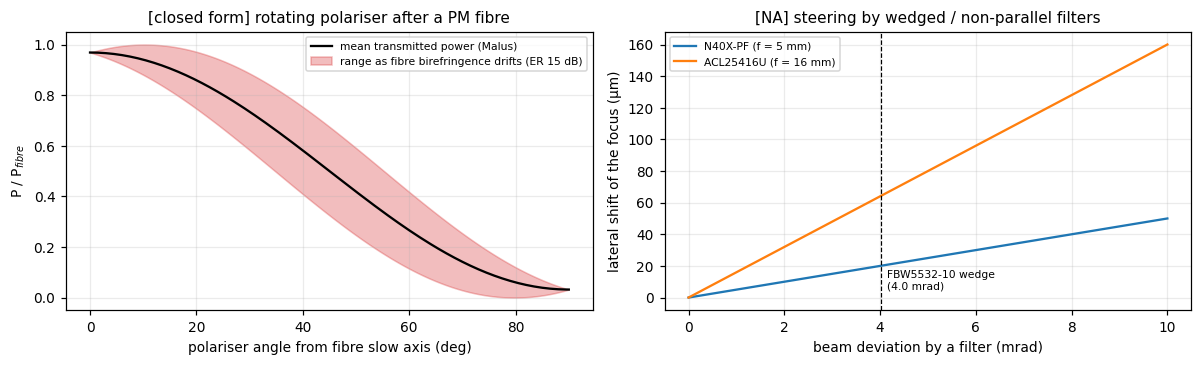

at 45 deg the power can wander by +/-17 % of P_fibre; at 0 deg (fixed, on the slow axis) it is stable to ~3.2 % worst case
ND plate (2 mm, tilted 3 deg): lateral beam shift 36 um -> irrelevant at a 7.5 mm pupil
the same plate between fibre and collimator would shift the focus by 0.68 mm


In [12]:
# ---- polarisation: why a rotating polariser is a poor power control after a PM fibre --------------
eps = 10 ** (-FIB_ER / 10)          # fraction of power in the fast axis
th = np.linspace(0, 90, 181)
t = np.radians(th)
mean = (1 - eps) * np.cos(t) ** 2 + eps * np.sin(t) ** 2
swing = 2 * np.sqrt(eps * (1 - eps)) * np.abs(np.sin(t) * np.cos(t))   # +/- as the fibre's phase drifts

delta = np.linspace(0, 10, 200) * 1e-3    # beam deviation (rad)
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axs[0]
ax.plot(th, mean, "k", label="mean transmitted power (Malus)")
ax.fill_between(th, mean - swing, mean + swing, color="C3", alpha=0.3,
                label=f"range as fibre birefringence drifts (ER {FIB_ER:.0f} dB)")
ax.set_xlabel("polariser angle from fibre slow axis (deg)"); ax.set_ylabel("P / P$_{fibre}$")
ax.set_title("[closed form] rotating polariser after a PM fibre"); ax.legend(fontsize=7)
ax = axs[1]
ax.plot(delta * 1e3, OBJ_F * delta / UM, label="N40X-PF (f = 5 mm)")
ax.plot(delta * 1e3, ACL_F * delta / UM, label="ACL25416U (f = 16 mm)")
dev = om.wedge_deviation(FBW_WEDGE, FBW_N)
ax.axvline(dev * 1e3, color="k", ls="--", lw=0.8)
ax.text(dev * 1e3 * 1.03, 5, f"FBW5532-10 wedge\n({dev*1e3:.1f} mrad)", fontsize=7)
ax.set_xlabel("beam deviation by a filter (mrad)"); ax.set_ylabel("lateral shift of the focus (µm)")
ax.set_title("[NA] steering by wedged / non-parallel filters"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
print(f"at 45 deg the power can wander by +/-{100*np.sqrt(eps*(1-eps)):.0f} % of P_fibre; "
      f"at 0 deg (fixed, on the slow axis) it is stable to ~{100*eps:.1f} % worst case")
print(f"ND plate ({ND_T/MM:.0f} mm, tilted {np.degrees(ND_TILT):.0f} deg): lateral beam shift "
      f"{om.plate_lateral_shift(ND_T, ND_N, ND_TILT)/UM:.0f} um -> irrelevant at a 7.5 mm pupil")
print(f"the same plate between fibre and collimator would shift the focus by {om.plate_focal_shift(ND_T, ND_N)/MM:.2f} mm")

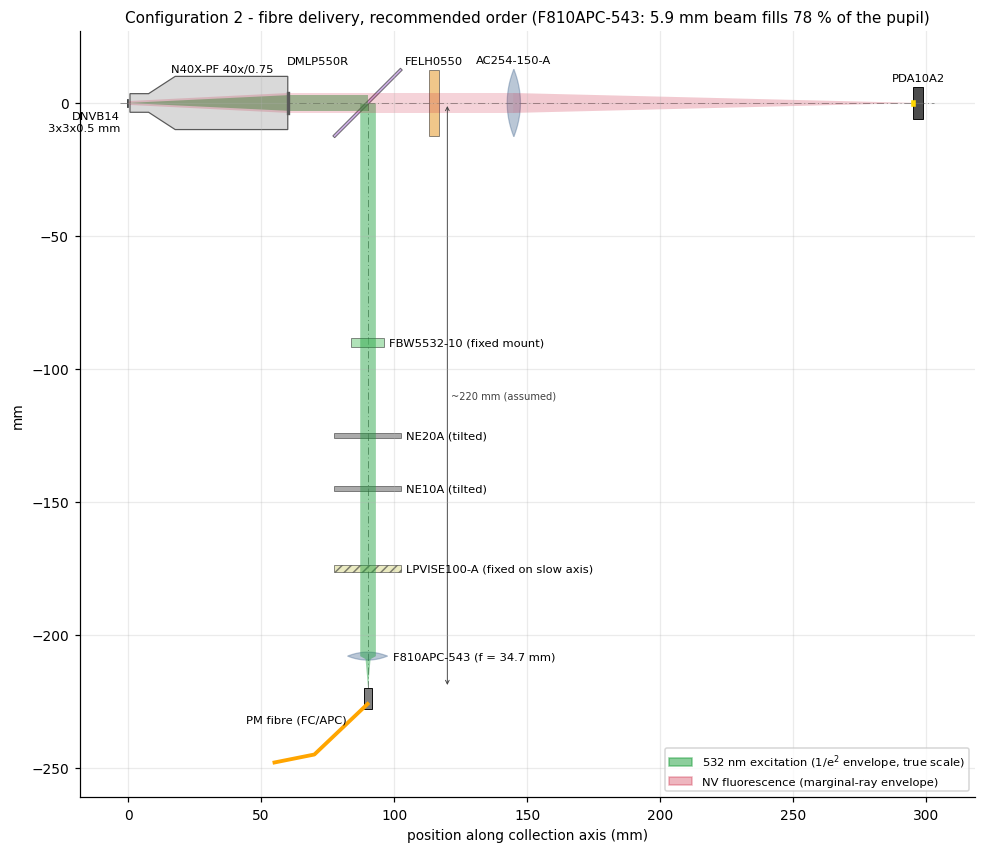

In [13]:
# ---- figure: configuration 2 (recommended order, F810APC-543 as the example collimator) ---------
name2 = "F810APC-543"
f_c = COLLIMATORS[name2][0]
W2 = om.collimated_diameter(MFD, LAM_EXC, f_c) / 2
y_src = -L_COLL_OBJ + L_OBJ_DICH
arm_2 = [("collimator", y_src + 12 * MM, f"{name2} (f = {f_c/MM:.1f} mm)", 7.5),
         ("pol", y_src + 45 * MM, "LPVISE100-A (fixed on slow axis)"),
         ("nd", y_src + 75 * MM, "NE10A (tilted)"), ("nd", y_src + 95 * MM, "NE20A (tilted)"),
         ("filter", y_src + 130 * MM, "FBW5532-10 (fixed mount)")]
y_coll = (y_src + 12 * MM) / MM


def w_arm2(y):
    # mm: cone from the fibre tip to the collimator, then collimated
    return np.where(y < y_coll, np.maximum((y - y_src / MM) * np.tan(theta_mode), 0.002), W2 / MM)


S2 = layout_dict("objective", OBJ_WD, X_PUP1, OBJ_PUPIL / 2, L_OBJ_DICH, L_OBJ_FELH, L_OBJ_LENS, L_LENS_DET,
                 W2, OBJ_F * OBJ_NA, OBJ_NA, arm_2, y_src, "fibre", w_arm2)
fig, ax = plt.subplots(figsize=(10.5, 10))
od.draw_system(ax, S2)
ax.legend(handles=od.legend_handles(), loc="lower right", fontsize=7.5)
od.vdim(ax, y_src / MM, 0, (X_PUP1 + L_OBJ_DICH) / MM + 30, f"~{(L_COLL_OBJ - L_OBJ_DICH)/MM:.0f} mm (assumed)")
ax.set_title(f"Configuration 2 - fibre delivery, recommended order ({name2}: {2*W2/MM:.1f} mm beam fills "
             f"{200*W2/OBJ_PUPIL:.0f} % of the pupil)")
plt.show()

### 2.2 Findings and things that are missing from the proposed list

**Which collimator** (table above): the choice depends on the job.
* **Ensemble** (§3, or the objective used for ensembles): **F240APC-532** gives a 1.3 mm beam, the same as today, so nothing downstream changes.
* **Confocal** (§4): **F810APC-543**. Its ≈ 5.9 mm beam fills ~78 % of the pupil and reaches the full NA.
* ACL25416U-B as a collimator: 2.7 mm, which is neither. It is not AR-coated at 532 nm and has no APC compensation, so it is not recommended.

**Easy to forget:**
1. **Laser-line filter after the fibre.** Silica fibre generates weak Raman and fluorescence background above 540 nm. Part of it is reflected by the DMLP550R, back-reflected by the diamond surface (~17 %), and reaches the detector through the FELH0550. Keep the FBW5532-10 *after* the collimator, in a fixed mount (it is wedged, see the plot). It is Ø12.5 mm, and a 5.9 mm beam clips ~0.3 % there, which is acceptable.
2. **Power control:** do not use the polariser as a rotating attenuator after a PM fibre. At 45° the fibre's temperature-dependent birefringence converts to **±17 % power wander** at 15 dB extinction ratio. It also rotates the excitation polarisation at the dichroic (532 nm sits *on* the DMLP550R's 533 nm band edge, where reflectance is polarisation-dependent) and on the NV axes. Keep the polariser **fixed on the slow axis** as a clean-up polariser and step the power with the ND filters. For continuous control, put a λ/2 plate + fixed polariser **before** the fibre (launch side), aligned to the PM axis.
3. **PM-axis launch** (λ/2 plate at the launch, see `procurement/fiber_coupling_stage.md`). Without it, 2. applies even with a fixed polariser.
4. **APC collimators** for an APC fibre: 0.5 mm (F240) / 2.3 mm (F810) off-centre on the lens otherwise (last column of the table).
5. **Power monitor pick-off** after the polariser/NDs (wedged sampler + photodiode) for normalising laser noise.
6. **Beam dump** for the light the dichroic transmits and the NDs reflect.
7. **Swap plan:** the two jobs want different collimators. Mount the collimator in an SM1 adapter so F240 ↔ F810 is a swap, not a rebuild.

**To measure before trusting the numbers:** collimated beam diameter out of the collimator (checks the MFD), coupling efficiency (power), and the power stability after the polariser over ~30 min while touching or heating the fibre.

---
## 3. Ensemble configuration: ACL25416U-B condenser for excitation *and* collection

The condenser replaces the objective. The laser (or F240-collimated fibre) beam is focused by the ACL, and the same ACL collects the PL, which then follows the existing path (DMLP550R → FELH0550 → AC254-150 → PDA10A2).

**What changes geometrically:**
* **Focal length 16 mm vs 5 mm.** For the same input beam the excitation spot is 3.2× larger and the depth of focus 10× longer. The magnification onto the detector drops from 30 to 9.4, so the detector sees a 3× wider field.
* **Working distance 7.3 mm (flat face → focus) vs 0.66 mm.** Much easier access for the MW antenna and magnet, but the lens sits in the near field of the antenna.
* **The collimated PL beam is up to Ø25 mm** (f·NA = 12.6 mm radius) instead of 7.5 mm. It now **overfills the 1″ filter and lens clear apertures**: the downstream optics, not the condenser, set the collection NA.
* **Focus sensitivity:** a slightly non-collimated input moves the focus by f²/R, 10× more than with the objective.
* **The condenser is not diffraction-limited.** That is irrelevant for a 1.3 mm excitation beam (it uses only the central 5 % of the aperture) and irrelevant for a non-imaging large-field collection. It would matter for imaging.
* The -B AR coating is **not specified at 532 nm**: expect several % reflection per surface (assumed 5 %). That costs excitation power and sends a back-reflection towards the laser, which matters for a free-space DPSS laser and is suppressed by the APC fibre in config 2.

In [14]:
X_PUP3 = ACL_F                    # principal plane ~ one focal length from the focus (ideal-lens model)
ACL_REAR = ACL_BFL + ACL_CT        # curved vertex position
L3_dich, L3_felh, L3_lens = (ACL_REAR - X_PUP3 + L_OBJ_DICH, ACL_REAR - X_PUP3 + L_OBJ_FELH,
                             ACL_REAR - X_PUP3 + L_OBJ_LENS)   # keep the downstream spacings of config 1
FOCUS_DEPTH_3 = param("Config 3: excitation focus depth", 250, "um", "assumed", "mid-plane of the 0.5 mm diamond", UM)
g3 = om.gaussian_focus(W_LASER, ACL_F, LAM_EXC, N_D)
f3 = focus_metrics(D_LASER, ACL_F, ACL_NA, n2=N_D, depth=FOCUS_DEPTH_3, rmax=25 * UM)
P3 = P_SAMPLE * (1 - ACL_R532) ** 2     # same laser power, minus two surfaces not AR-coated at 532 nm
w_top, w_bot = om.beam_in_diamond(W_LASER, ACL_F, LAM_EXC, FOCUS_DEPTH_3, np.array([0, T_DIAM]))
display(pd.DataFrame({"objective (config 1)": [g1["NA_eff"], 2 * g1["w0"] / UM, g1["zR"] / UM,
                                               2 * om.beam_in_diamond(W_LASER, OBJ_F, LAM_EXC, FOCUS_DEPTH_1, np.array([0, T_DIAM])).max() / UM,
                                               2 * P_SAMPLE / (np.pi * g1["w0"]**2) / 1e10, f1_depth["strehl"]],
                      "ACL25416U-B (config 3)": [g3["NA_eff"], 2 * g3["w0"] / UM, g3["zR"] / UM, 2 * max(w_top, w_bot) / UM,
                                                 2 * P3 / (np.pi * g3["w0"]**2) / 1e10, f3["strehl"]]},
                     index=["effective excitation NA", "[GB] waist 1/e2 dia. (um)", "[GB] Rayleigh range in diamond (um)",
                            "[GB] largest beam dia. inside the diamond (um)", "[GB] peak intensity (MW/cm2) at the stated power",
                            "[WO] Strehl at the focus depth"]))
print(f"[WO] vs [GB] waist: {2*f3['w_e2']/UM:.2f} vs {2*g3['w0']/UM:.2f} um")

,objective (config 1),ACL25416U-B (config 3)
effective excitation NA,0.140,0.044
[GB] waist 1/e2 dia. (um),2.419,7.741
[GB] Rayleigh range in diamond (um),20.908,214.102
[GB] largest beam dia. inside the diamond (um),46.344,11.901
[GB] peak intensity (MW/cm2) at the stated power,0.131,0.012
[WO] Strehl at the focus depth,0.999,1.000


[WO] vs [GB] waist: 7.75 vs 7.74 um


In [15]:
# [MC] collection with the condenser, and what-if detector lenses
stops3 = collection_stops(L3_dich, L3_felh, L3_lens)
mc3 = run_mc(W_LASER, ACL_F, FOCUS_DEPTH_3, ACL_F, ACL_NA, stops3, L3_lens)
mc3_f50 = run_mc(W_LASER, ACL_F, FOCUS_DEPTH_3, ACL_F, ACL_NA, stops3, L3_lens, f2=50 * MM)
mc3_acl = run_mc(W_LASER, ACL_F, FOCUS_DEPTH_3, ACL_F, ACL_NA, stops3, L3_lens, f2=ACL_F)
res_all = {"1: objective + AC254-150 (as built)": mc1, "1': objective + f=50 mm lens": mc1_f50,
           "3: ACL + AC254-150": mc3, "3': ACL + f=50 mm lens": mc3_f50, "3'': ACL + 2nd ACL as detector lens": mc3_acl}
display(stage_table(res_all))
display(pl_beam_sizes(mc3, [("DMLP550R", L3_dich), ("FELH0550", L3_felh), ("AC254-150", L3_lens)]))
eff_NA = np.percentile(np.hypot(mc3["rays"]["px"], mc3["rays"]["py"])[mc3["rays"]["pre"]], 100) / ACL_F
print(f"[MC] largest pupil height that passes all 1-inch stops -> effective collection NA ~ {eff_NA:.2f} (condenser NA {ACL_NA})")
print(f"[NA] detector back-projected into the sample: radius {R_DET*ACL_F/AC_F/UM:.0f} um with the AC254-150")

alphas = np.array([0, 5, 10, 20, 40])         # 1/cm, illustrative only
sens = [(100 * run_mc(W_LASER, OBJ_F, FOCUS_DEPTH_1, OBJ_F, OBJ_NA, stops1, L_OBJ_LENS, alpha=a * 100, n=400_000)["on detector"],
         100 * run_mc(W_LASER, ACL_F, FOCUS_DEPTH_3, ACL_F, ACL_NA, stops3, L3_lens, alpha=a * 100, n=400_000)["on detector"])
        for a in alphas]
display(pd.DataFrame(sens, index=pd.Index(alphas, name="absorption alpha (1/cm), UNKNOWN"),
                     columns=["config 1 on detector (% of emitted)", "config 3 on detector (% of emitted)"]).assign(
    **{"ratio 3/1": lambda d: d.iloc[:, 1] / d.iloc[:, 0]}))

,1: objective + AC254-150 (as built),1': objective + f=50 mm lens,3: ACL + AC254-150,3': ACL + f=50 mm lens,3'': ACL + 2nd ACL as detector lens
escape (no TIR) (% of 4pi),3.518,3.518,3.518,3.518,3.518
within lens NA (% of 4pi),2.026,2.026,2.256,2.256,2.256
through filters/dichroic/lens stops (% of 4pi),2.026,2.026,1.670,1.670,1.670
on detector (% of 4pi),0.705,1.494,1.538,1.670,1.670


,distance from pupil (mm),PL beam dia. 95% (mm),PL beam dia. max (mm)
plane,,,
DMLP550R,35.3,24.867,25.856
FELH0550,60.3,24.984,26.272
AC254-150,90.3,25.149,26.778


[MC] largest pupil height that passes all 1-inch stops -> effective collection NA ~ 0.70 (condenser NA 0.79)
[NA] detector back-projected into the sample: radius 54 um with the AC254-150


,config 1 on detector (% of emitted),config 3 on detector (% of emitted),ratio 3/1
"absorption alpha (1/cm), UNKNOWN",,,
0,0.717,1.545,2.155
5,0.757,1.526,2.017
10,0.795,1.507,1.897
20,0.868,1.470,1.694
40,1.004,1.398,1.393


**Light level: what can and cannot be estimated.** The robust output of the model is the **fraction of the emitted PL that reaches the detector** (tables above), and hence the **ratio between configurations**. The absolute PL power also needs the fraction of the 532 nm power absorbed by NV⁻ in 0.5 mm of DNVB14 (absorption coefficient not known), the NV⁻/NV⁰ ratio and the quantum efficiency under your excitation. These are not in any datasheet. The cell below therefore converts a **measured** emitted-PL level into detector power, rather than inventing one. **Measure it:** put the S120C power sensor where the PDA10A2 sits, behind the FELH0550, with the laser on. Then check the inferred emitted PL against the absorbed-power bound.

In [16]:
P_PL_measured = param("PL power measured at the detector plane", None, "nW", "UNKNOWN",
                      "measure with S120C behind FELH0550 (config 1); enter here", 1e-9)
T_train = DICH_TPL * FELH_T            # filters/dichroic in the PL path (objective T separately)
rows = []
for lab, r, T_opt in [("1 (as built)", mc1, OBJ_T), ("1' f=50 mm", mc1_f50, OBJ_T), ("3 ACL", mc3, 1.0),
                      ("3' ACL + f=50 mm", mc3_f50, 1.0), ("3'' ACL + ACL", mc3_acl, 1.0)]:
    rows.append({"configuration": lab, "detector power per 1 uW of emitted PL (nW)": 1e3 * r["on detector"] * T_train * T_opt,
                 "relative to config 1": (r["on detector"] * T_opt) / (mc1["on detector"] * OBJ_T)})
light = pd.DataFrame(rows).set_index("configuration")
if P_PL_measured is not None:
    emitted = P_PL_measured / (mc1["on detector"] * T_train * OBJ_T)
    light["predicted detector power (nW)"] = light.iloc[:, 0] * emitted / 1e-6
    print(f"implied emitted PL (4pi): {emitted/1e-6:.2f} uW = {100*emitted/P_SAMPLE:.2f} % of the excitation power")
display(light)
print("(ACL transmission taken as 1 in the PL band - its -B coating is specified there; objective T is assumed)")

,detector power per 1 uW of emitted PL (nW),relative to config 1
configuration,,
1 (as built),4.570,1.000
1' f=50 mm,9.684,2.119
3 ACL,12.456,2.726
3' ACL + f=50 mm,13.529,2.960
3'' ACL + ACL,13.529,2.960


(ACL transmission taken as 1 in the PL band - its -B coating is specified there; objective T is assumed)


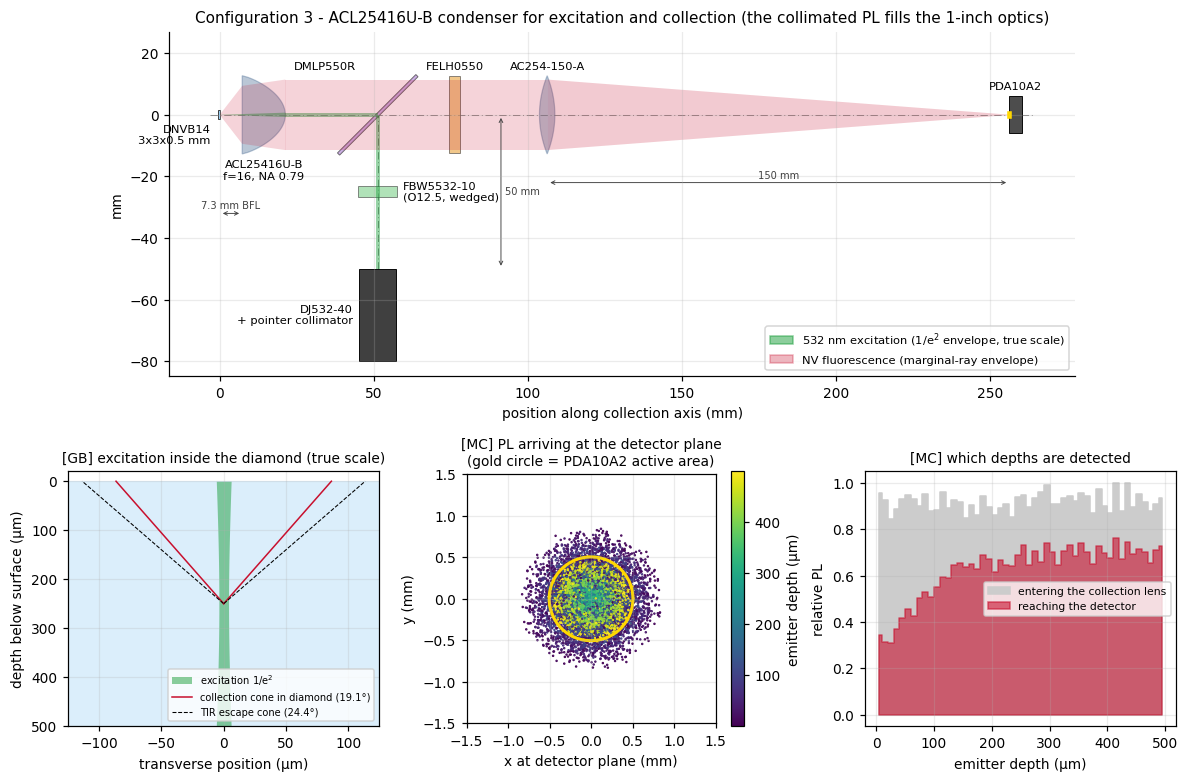

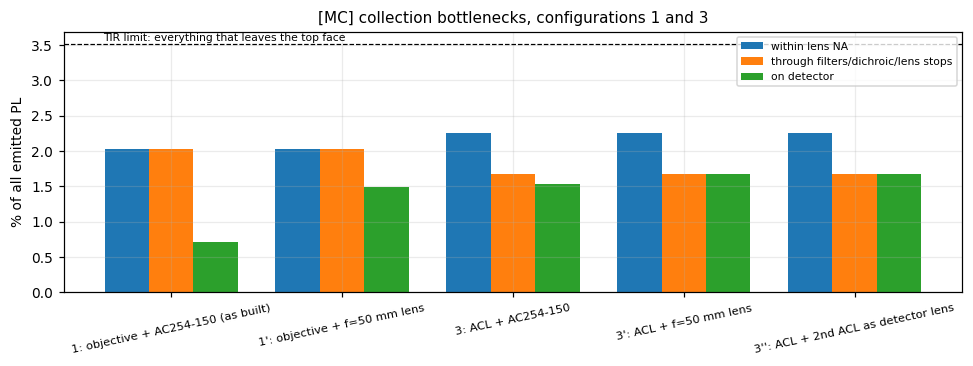

In [17]:
# ---- figure: configuration 3 -------------------------------------------------------------
S3 = layout_dict("asphere", ACL_BFL, X_PUP3, ACL_F * ACL_NA, L3_dich, L3_felh, L3_lens, L_LENS_DET,
                 W_LASER, AC_CA / 2, ACL_NA, arm_1, -L_LASER_DICH, "laser",
                 lambda y: np.full_like(y, W_LASER / MM))
S3["x_pupil"] = ACL_REAR / MM          # draw the collimated PL from the lens rear face
zoom3 = dict(z_um=zd / UM, w_um=om.beam_in_diamond(W_LASER, ACL_F, LAM_EXC, FOCUS_DEPTH_3, zd) / UM, NA_coll=ACL_NA,
             focus_um=FOCUS_DEPTH_3 / UM, title="[GB] excitation inside the diamond (true scale)")
x3d = S3["x_dich"]
dims3 = [("h", 0, ACL_BFL / MM, -32, "7.3 mm BFL"),
         ("h", S3["x_lens"], S3["x_det"], -22, "150 mm"),
         ("v", -L_LASER_DICH / MM, 0, x3d + 40, "50 mm")]
fig = config_figure(S3, "Configuration 3 - ACL25416U-B condenser for excitation and collection "
                        "(the collimated PL fills the 1-inch optics)", zoom3, mc3, dims3)
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.4))
labels = list(res_all)
stages = ["within lens NA", "through filters/dichroic/lens stops", "on detector"]
xx = np.arange(len(labels))
for i, s in enumerate(stages):
    ax.bar(xx + (i - 1) * 0.26, [100 * res_all[l][s] for l in labels], 0.26, label=s)
ax.axhline(100 * om.escape_cone_fraction_fresnel(1.0), color="k", ls="--", lw=0.8)
ax.text(-0.4, 100 * om.escape_cone_fraction_fresnel(1.0) + 0.05, "TIR limit: everything that leaves the top face", fontsize=7)
ax.set_xticks(xx); ax.set_xticklabels(labels, rotation=12, fontsize=7.5)
ax.set_ylabel("% of all emitted PL"); ax.set_title("[MC] collection bottlenecks, configurations 1 and 3"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

### 3.1 Findings for the ensemble configuration

* **The condenser's higher NA buys almost nothing by itself.** Inside the diamond, 0.79 vs 0.75 means 19.1° vs 18.1°, only ~11 % more solid angle. And the 1″ filter, dichroic and lens clip the Ø25 mm beam back to an effective NA ≈ 0.70. **[NA]/[MC]**
* **Where it does gain** is the **field**. At M = 9.4 the PDA10A2 sees a ≈ Ø110 µm region instead of Ø34 µm, and a much longer depth range of the (now almost cylindrical, ≈ 8–12 µm wide) excited column. Net: ≈ **2.2× more PL on the same detector** than today. That drops to 1.4× if the diamond absorbs strongly (unknown, see the α table), and rises to ≈ 2.7× if the objective really transmits only the assumed 80 %.
* **The detector lens is the cheapest lever in both configurations.** With a shorter focal length in front of the PDA10A2 (f ≈ 50 mm achromat, or the second ACL25416U-B if you have it), essentially everything that passes the 1″ optics lands on the detector. **[MC]** The same fix applied to the objective (config 1′) gives most of the benefit without touching the excitation side.
* **Excitation:** ≈ 7.7 µm (1/e²) waist, ≤ 12 µm anywhere in the plate, Rayleigh range ≈ 0.2 mm, so the beam is nearly uniform through the 0.5 mm plate. That is a larger, lower-intensity volume, which is better for ensemble ODMR (less saturation and power broadening, more NVs). Strehl ≈ 1: diamond-induced aberration is irrelevant at NA 0.04.
* **Alignment-sensitive:** the lateral detector position (the PL spot on the detector is now larger, and more light sits near the edge), the collimation of the input beam (focus moves 10× more than with the objective), and centring of the 25 mm collimated beam on the 1″ optics.
* **Bottleneck ranking (condenser + AC254-150):** the diamond's total internal reflection (dominant, fixed by the geometry) → the 1″ clear apertures → the Ø1 mm detector. Beating the total-internal-reflection limit needs a different geometry (a solid-immersion or index-matched extraction, or collecting from the side faces), not a better lens.
* **Light level:** only relative numbers are trustworthy until the PL power is measured once (cell above).

---
## 4. Single-NV confocal configuration (N40X-PF + AC254-150 + pinhole + PDA10A2)

Confocal geometry: the objective focuses the excitation to a diffraction-limited spot **[WO]**. The same objective and the AC254-150 image that spot onto a pinhole at the AC254 focal plane, with lateral magnification M = 150/5 = **30**. Only light from near the focus passes the pinhole. The PDA10A2 sits directly behind the pinhole.

Everything here uses the **[WO]** scalar Debye model, including the air→diamond interface and the objective's built-in 0.17 mm cover-glass correction. Confocal response = excitation PSF × (detection PSF ⊛ pinhole).

[DL] Airy unit at the pinhole (700 nm): 34 um;  in the sample 1.14 um


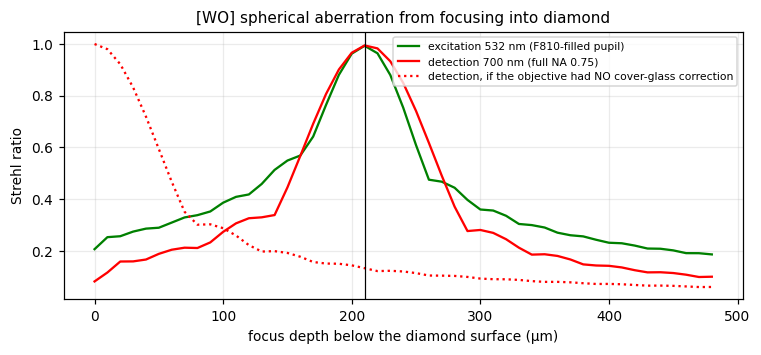

best depth: 210 um (Strehl exc 0.99, det 0.99); surface: exc 0.21, det 0.08. Stage moves 145 um to get there (WD 0.66 mm leaves 515 um clearance)


In [18]:
PINHOLES = param("Pinhole diameters evaluated", "5,10,15,20,25,30,40,50,75,100,150,200", "um", "assumed",
                 "typical kit; check which sizes you have")
PINHOLES = np.array([5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200]) * UM
M_CONF = AC_F / OBJ_F
AU_img = om.airy_unit(LAM_PL, OBJ_NA) * M_CONF
print(f"[DL] Airy unit at the pinhole (700 nm): {AU_img/UM:.0f} um;  in the sample {om.airy_unit(LAM_PL, OBJ_NA)/UM:.2f} um")

# Strehl vs depth: excitation (532, F810-filled pupil) and detection (700, uniform pupil), cover-glass correction on
D_F810 = 2 * om.q_radius(om.q_propagate(om.q_from_waist(om.collimated_diameter(MFD, LAM_EXC, 34.74 * MM) / 2, LAM_EXC),
                                        L_COLL_OBJ), LAM_EXC)
depths = np.linspace(0, 480, 49) * UM
FexcF = om.Focus(LAM_EXC, OBJ_NA, OBJ_F, D_F810 / 2, N_D, t_cg=OBJ_TCG)
Fdet = om.Focus(LAM_PL, OBJ_NA, OBJ_F, None, N_D, t_cg=OBJ_TCG)
Fdet0 = om.Focus(LAM_PL, OBJ_NA, OBJ_F, None, N_D, t_cg=0.0)
S_exc = np.array([FexcF.best_focus(d)[1] for d in depths])
S_det = np.array([Fdet.best_focus(d)[1] for d in depths])
S_det0 = np.array([Fdet0.best_focus(d)[1] for d in depths])
DEPTH_4 = depths[np.argmax(S_exc * S_det)]
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.plot(depths / UM, S_exc, "g", label="excitation 532 nm (F810-filled pupil)")
ax.plot(depths / UM, S_det, "r", label="detection 700 nm (full NA 0.75)")
ax.plot(depths / UM, S_det0, "r:", label="detection, if the objective had NO cover-glass correction")
ax.axvline(DEPTH_4 / UM, color="k", lw=0.8)
ax.set_xlabel("focus depth below the diamond surface (µm)"); ax.set_ylabel("Strehl ratio")
ax.set_title("[WO] spherical aberration from focusing into diamond"); ax.legend(fontsize=7); plt.tight_layout(); plt.show()
zf4, _ = FexcF.best_focus(DEPTH_4)
print(f"best depth: {DEPTH_4/UM:.0f} um (Strehl exc {S_exc.max():.2f}, det {S_det[np.argmax(S_exc*S_det)]:.2f}); "
      f"surface: exc {S_exc[0]:.2f}, det {S_det[0]:.2f}. Stage moves {zf4/UM:.0f} um to get there "
      f"(WD {OBJ_WD/MM:.2f} mm leaves {(OBJ_WD - zf4)/UM:.0f} um clearance)")

In [19]:
# ---- confocal PSFs at the chosen depth ---------------------------------------------------------
r4 = np.linspace(0, 16, 161) * UM
z4 = DEPTH_4 + np.linspace(-40, 40, 161) * UM
exc_opts = {"current laser (1.4 mm, under-filled)": om.Focus(LAM_EXC, OBJ_NA, OBJ_F, W_LASER, N_D, t_cg=OBJ_TCG),
            "fibre + F810 (pupil filled)": FexcF}
I_exc = {k: F.intensity(r4, z4, zf4) for k, F in exc_opts.items()}


def conf_metrics(Iex, D):
    h = Iex * D
    iz = np.unravel_index(np.argmax(h), h.shape)[0]
    sheet = np.trapezoid(h * 2 * np.pi * r4, r4, axis=1)
    V = np.trapezoid(sheet, z4) ** 2 / np.trapezoid(np.trapezoid(h ** 2 * 2 * np.pi * r4, r4, axis=1), z4)   # effective volume
    return dict(lat=om.radial_fwhm(r4, h[iz]), ax=om.fwhm(z4, h[:, 0]), sheet=om.fwhm(z4, sheet),
                D_focus=D[:, 0].max(), V=V, h=h)


rows, cm = [], {}
for d_ph in list(PINHOLES) + [2 * R_DET]:
    a_obj = d_ph / 2 / M_CONF
    half = max(20 * UM, a_obj + 18 * UM)
    D = om.pinhole_detection_map(Fdet, r4, z4, a_obj, z_f=zf4, half=half, N=int(2 * half / (0.09 * UM)) // 2 * 2)
    for k, Iex in I_exc.items():
        m = conf_metrics(Iex, D)
        cm[(d_ph, k)] = m
        rows.append({"pinhole (um)": "PDA10A2 only (1010)" if d_ph > 250 * UM else round(d_ph / UM),
                     "pinhole / AU": d_ph / AU_img, "excitation": k,
                     "lateral FWHM (um)": m["lat"] / UM, "axial FWHM, point (um)": m["ax"] / UM,
                     "axial FWHM, thin NV layer (um)": m["sheet"] / UM,
                     "in-focus transmission": m["D_focus"], "effective volume (um^3)": m["V"] / UM ** 3,
                     "NVs in volume (DNVB14)": om.nv_per_volume(NV_PPM, m["V"])})
conf = pd.DataFrame(rows)
for k in I_exc:
    display(Markdown(f"**Excitation: {k}** (NaN = wider than the +/-40 um window, i.e. no sectioning)"))
    display(conf[conf.excitation == k].drop(columns="excitation").set_index("pinhole (um)").round(3))

**Excitation: current laser (1.4 mm, under-filled)** (NaN = wider than the +/-40 um window, i.e. no sectioning)

,pinhole / AU,lateral FWHM (um),"axial FWHM, point (um)","axial FWHM, thin NV layer (um)",in-focus transmission,effective volume (um^3),NVs in volume (DNVB14)
pinhole (um),,,,,,,
5,0.146,0.402,5.155,11.237,0.092,16.960,1.345e+07
10,0.293,0.427,5.177,11.034,0.248,18.532,1.470e+07
15,0.439,0.465,5.226,10.759,0.423,20.746,1.646e+07
20,0.585,0.535,5.350,10.486,0.611,23.927,1.898e+07
25,0.732,0.636,5.579,10.219,0.727,27.457,2.178e+07
30,0.878,0.756,5.973,9.975,0.783,31.440,2.494e+07
40,1.171,0.986,7.584,10.373,0.823,41.857,3.321e+07
50,1.464,1.186,9.155,10.544,0.861,54.369,4.313e+07
75,2.196,1.381,12.614,12.484,0.908,91.005,7.220e+07


**Excitation: fibre + F810 (pupil filled)** (NaN = wider than the +/-40 um window, i.e. no sectioning)

,pinhole / AU,lateral FWHM (um),"axial FWHM, point (um)","axial FWHM, thin NV layer (um)",in-focus transmission,effective volume (um^3),NVs in volume (DNVB14)
pinhole (um),,,,,,,
5,0.146,0.303,3.337,3.822,0.092,2.077,1.648e+06
10,0.293,0.310,3.342,3.901,0.248,2.290,1.817e+06
15,0.439,0.321,3.353,4.029,0.423,2.621,2.079e+06
20,0.585,0.340,3.381,4.264,0.611,3.169,2.514e+06
25,0.732,0.362,3.429,4.555,0.727,3.860,3.062e+06
30,0.878,0.386,3.504,4.915,0.783,4.709,3.736e+06
40,1.171,0.421,3.746,5.966,0.823,6.989,5.544e+06
50,1.464,0.419,3.949,7.318,0.861,9.783,7.762e+06
75,2.196,0.422,4.129,10.657,0.908,18.239,1.447e+07


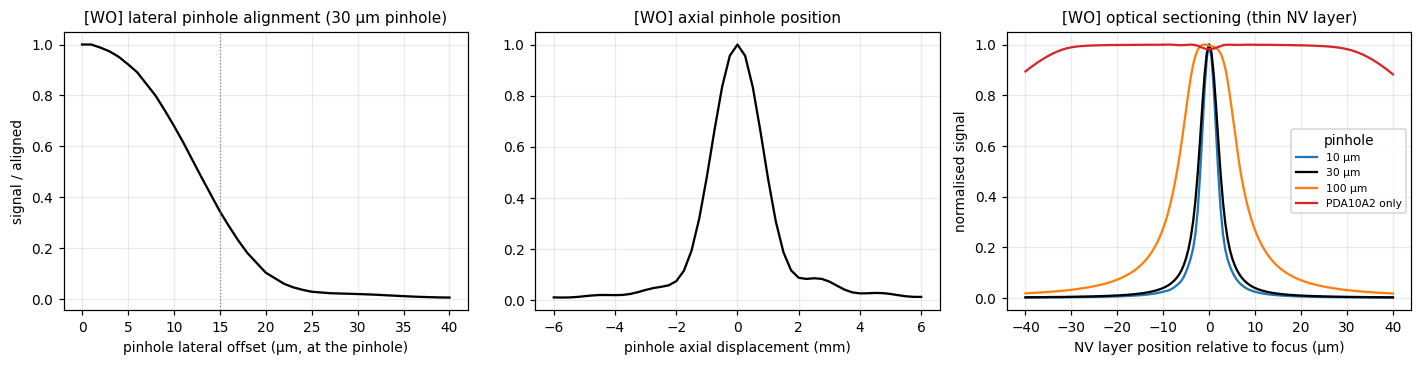

recommended pinhole ~1 AU: 30 um; lateral tolerance (-10 %): 5.7 um at the pinhole; axial (-10 %): +/-0.2 mm
PDA10A2 behind the pinhole: cone NA 0.025 -> the O1 mm detector catches everything within 20 mm of the pinhole; no relay lens needed


In [20]:
# ---- misalignment / defocus sensitivity for a ~1 AU pinhole ------------------------------------
PH_REC = PINHOLES[np.argmin(np.abs(PINHOLES - 1.0 * AU_img))]
a_rec = PH_REC / 2 / M_CONF
lat = np.linspace(0, 40, 41) * UM                  # pinhole offset at the pinhole plane
D_lat = om.pinhole_detection_map(Fdet, lat / M_CONF, [DEPTH_4], a_rec, z_f=zf4)[0]
ax_shift = np.linspace(-6, 6, 49) * MM             # pinhole displacement along the axis
# axial pinhole shift dz_img is equivalent to refocusing the detection by dz_img / M^2 (in air)
D_ax = np.array([Fdet.encircled(a_rec, DEPTH_4, zf4 + dz / M_CONF ** 2)[0] for dz in ax_shift])
sample_dz = (z4 - DEPTH_4)
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4))
axs[0].plot(lat / UM, D_lat / D_lat[0], "k")
axs[0].axvline(PH_REC / 2 / UM, color="0.5", ls=":", lw=0.8)
axs[0].set_xlabel("pinhole lateral offset (µm, at the pinhole)"); axs[0].set_ylabel("signal / aligned")
axs[0].set_title(f"[WO] lateral pinhole alignment ({PH_REC/UM:.0f} µm pinhole)")
axs[1].plot(ax_shift / MM, D_ax / D_ax.max(), "k")
axs[1].set_xlabel("pinhole axial displacement (mm)"); axs[1].set_title("[WO] axial pinhole position")
k_f = "fibre + F810 (pupil filled)"
for d_ph, c in [(10 * UM, "C0"), (PH_REC, "k"), (100 * UM, "C1"), (2 * R_DET, "C3")]:
    m = cm[(d_ph, k_f)]
    s = np.trapezoid(m["h"] * 2 * np.pi * r4, r4, axis=1)
    axs[2].plot(sample_dz / UM, s / s.max(), color=c, label=f"{d_ph/UM:.0f} µm" if d_ph < 250 * UM else "PDA10A2 only")
axs[2].set_xlabel("NV layer position relative to focus (µm)"); axs[2].set_ylabel("normalised signal")
axs[2].set_title("[WO] optical sectioning (thin NV layer)"); axs[2].legend(fontsize=7, title="pinhole")
plt.tight_layout(); plt.show()
print(f"recommended pinhole ~1 AU: {PH_REC/UM:.0f} um; lateral tolerance (-10 %): "
      f"{np.interp(0.9, (D_lat/D_lat[0])[::-1], lat[::-1])/UM:.1f} um at the pinhole; axial (-10 %): "
      f"+/-{np.ptp(ax_shift[D_ax/D_ax.max() > 0.9])/2/MM:.1f} mm")
NA_img = OBJ_NA / M_CONF
print(f"PDA10A2 behind the pinhole: cone NA {NA_img:.3f} -> the O1 mm detector catches everything within "
      f"{(R_DET - PH_REC/2)/NA_img/MM:.0f} mm of the pinhole; no relay lens needed")

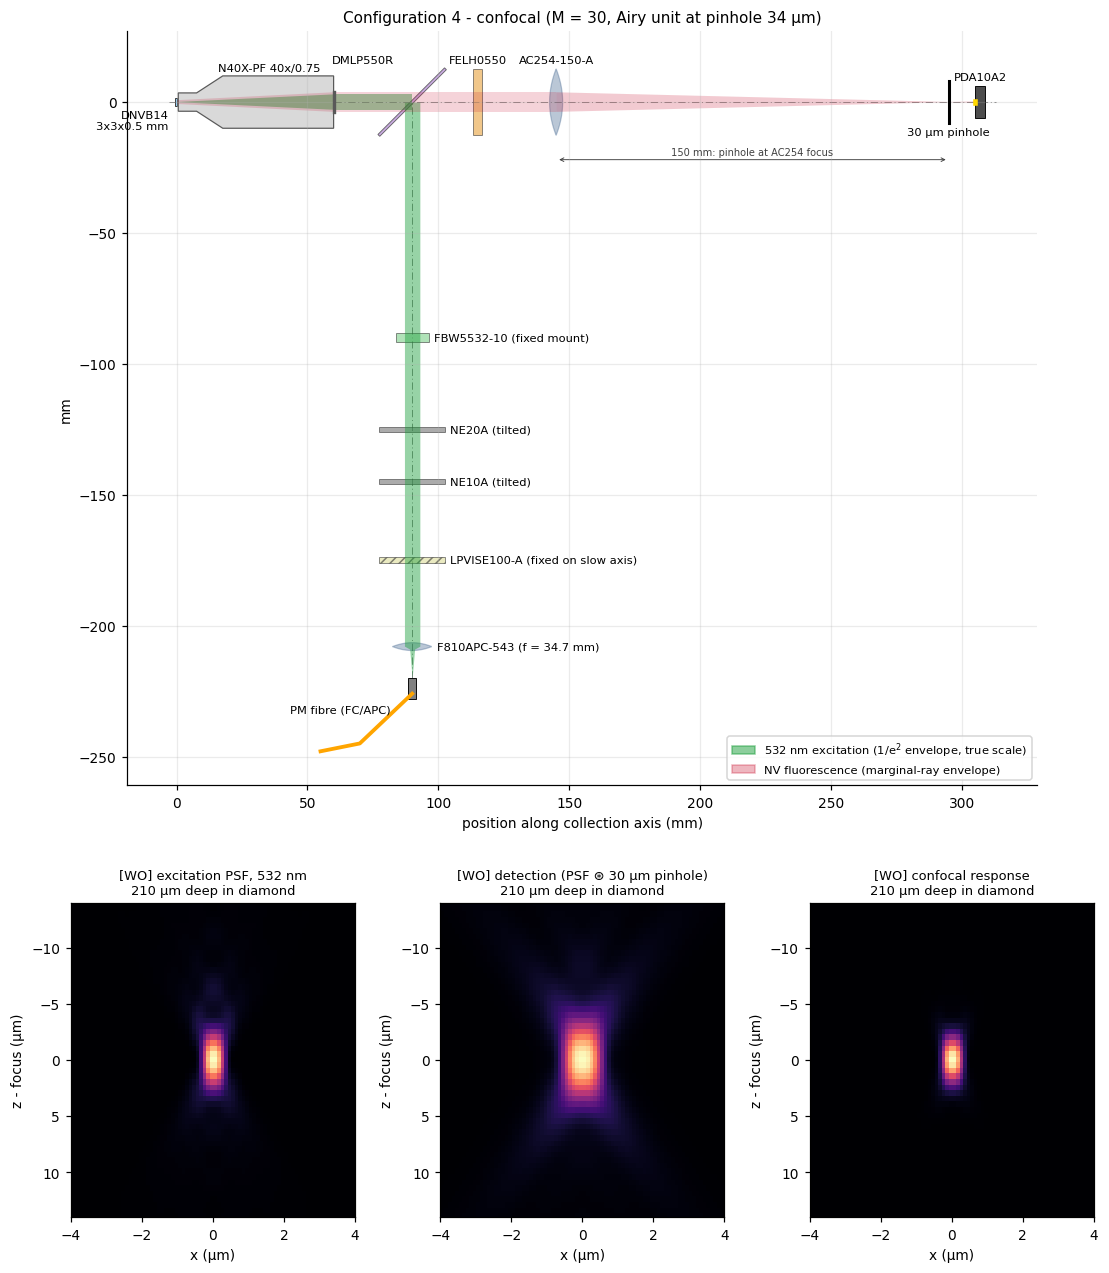

In [21]:
# ---- figure: configuration 4 ---------------------------------------------------------------------
x_ph = X_PUP1 + L_OBJ_LENS + AC_F
S4 = layout_dict("objective", OBJ_WD, X_PUP1, OBJ_PUPIL / 2, L_OBJ_DICH, L_OBJ_FELH, L_OBJ_LENS, AC_F + 10 * MM,
                 D_F810 / 2, OBJ_F * OBJ_NA, OBJ_NA, arm_2, y_src, "fibre", w_arm2,
                 x_pinhole=x_ph, r_pinhole=PH_REC / 2, r_after=PH_REC / 2 + NA_img * 10 * MM)
S4["pinhole_label"] = f"{PH_REC/UM:.0f} µm pinhole"
fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(2, 3, height_ratios=[2.4, 1], hspace=0.22, wspace=0.3)
ax = fig.add_subplot(gs[0, :])
od.draw_system(ax, S4)
ax.legend(handles=od.legend_handles(), loc="lower right", fontsize=7.5)
od.hdim(ax, (X_PUP1 + L_OBJ_LENS) / MM, x_ph / MM, -22, "150 mm: pinhole at AC254 focus")
ax.set_title(f"Configuration 4 - confocal (M = {M_CONF:.0f}, Airy unit at pinhole {AU_img/UM:.0f} µm)")
ext = [-r4[-1] / UM, r4[-1] / UM, (z4[-1] - DEPTH_4) / UM, (z4[0] - DEPTH_4) / UM]


def mirror(A):
    return np.hstack([A[:, ::-1], A])


m_rec = cm[(PH_REC, k_f)]
D_rec = m_rec["h"] / np.maximum(I_exc[k_f], 1e-30)
for j, (A, t) in enumerate([(I_exc[k_f], "excitation PSF, 532 nm"), (D_rec, f"detection (PSF ⊛ {PH_REC/UM:.0f} µm pinhole)"),
                            (m_rec["h"], "confocal response")]):
    a = fig.add_subplot(gs[1, j])
    a.imshow(mirror(A / A.max()), extent=ext, aspect="auto", cmap="magma", origin="upper")
    a.set_title(f"[WO] {t}\n{DEPTH_4/UM:.0f} µm deep in diamond", fontsize=8.5)
    a.set_xlabel("x (µm)"); a.set_ylabel("z - focus (µm)"); a.grid(False)
    a.set_xlim(-4, 4); a.set_ylim(14, -14)
plt.show()

### 4.1 Findings for the confocal configuration

* **The geometry is sensible:** M = 30 puts the Airy unit at ≈ 34 µm on the pinhole, so a **30–40 µm pinhole** (~1 AU) is the standard choice. 50 µm trades a little sectioning for signal. Lateral alignment must hold to a few µm at the pinhole, so the pinhole needs an XY translator (you own `ST1XY-S/M`). Axially, ±0.3 mm costs 10 % (M² = 900 relaxes it). The PDA10A2 can sit directly behind the pinhole, within ≈ 20 mm, with no relay lens.
* **The pupil must be filled for confocal work.** With the 30 µm pinhole, today's 1.4 mm beam gives a 0.76 µm lateral / 10 µm axial (thin-layer) response. The fibre + F810 option (§2) gives 0.39 µm / 4.9 µm, a ~7× smaller volume. With the under-filled beam, almost all the sectioning comes from the pinhole.
* **The dominant optical limitation is the diamond itself.** Focusing an NA 0.75 dry objective into n = 2.42 causes strong spherical aberration. Because the N40X-PF is **corrected for a 0.17 mm cover glass that is not there**, the focus at the diamond *surface* is badly aberrated (Strehl 0.2 for excitation, 0.08 for detection). The diamond's own aberration cancels that correction at a depth of ≈ 200 µm (210 µm in this model), where both are near diffraction-limited (Strehl ≈ 0.99). **Work at that depth**, or check whether the objective has a correction collar. Reaching it takes ≈ 145 µm of stage travel: a 58 µm offset from the missing cover glass, plus ≈ 0.4 µm per µm of depth. Stage readings are therefore not depths. There is ≈ 0.5 mm of working-distance clearance.
* **Why the diamond, not the optics, rules out single-NV work:** DNVB14 has 4.5 ppm NV, i.e. ≈ 8 × 10⁵ NV per µm³. Even the best confocal volume here (≈ 2–5 µm³ effective) holds **~10⁶ NVs** (table above), so no optics can isolate a single centre in this sample. That needs ≲ 1 NV per few µm³, i.e. NV density at the ppt level (electronic-grade diamond, or sparse implanted NVs).
* **Detector:** a single NV gives ~10⁵ photons/s ≈ 30 fW (see `procurement/apd430a_single_nv_analysis.md`). This is orders of magnitude below what a PDA10A2 can detect. Single-NV work needs a photon counter. With the current optics and diamond, configuration 4 is a **depth-resolved ensemble confocal**, and it is useful as that.
* **Background:** the FELH0550 passes the diamond first-order Raman line at 573 nm (1332 cm⁻¹ from 532 nm). This is negligible against a dense ensemble, but it dominates a single-NV signal. A 600–650 nm longpass is the standard choice for single NVs.
* **Other optics:** the AC254-150-A (coated for 400–700 nm) and the DMLP550R are fine. The objective's transmission above 700 nm and the vectorial effects not included here change the numbers by ~10 %, not the conclusions.

---
## 5. Side-by-side comparison

In [22]:
k_cur = "current laser (1.4 mm, under-filled)"
summary = pd.DataFrame({
    "1 current": {"excitation spot 1/e2 dia. (um)": 2 * g1["w0"] / UM, "excitation NA (effective)": g1["NA_eff"],
                  "collection NA (effective)": OBJ_NA, "PL on detector (% of 4pi) [MC]": 100 * mc1["on detector"],
                  "relative detected PL": 1.0, "depth selectivity": "~detector-limited, tens of um"},
    "1' current + f=50 mm det. lens": {"excitation spot 1/e2 dia. (um)": 2 * g1["w0"] / UM, "excitation NA (effective)": g1["NA_eff"],
                  "collection NA (effective)": OBJ_NA, "PL on detector (% of 4pi) [MC]": 100 * mc1_f50["on detector"],
                  "relative detected PL": mc1_f50["on detector"] / mc1["on detector"], "depth selectivity": "weak"},
    "2 fibre + F240 (ensemble)": {"excitation spot 1/e2 dia. (um)": 2 * LAM_EXC * OBJ_F / (np.pi * om.collimated_diameter(MFD, LAM_EXC, 7.86*MM) / 2) / UM,
                  "excitation NA (effective)": om.collimated_diameter(MFD, LAM_EXC, 7.86*MM) / 2 / OBJ_F,
                  "collection NA (effective)": OBJ_NA, "PL on detector (% of 4pi) [MC]": np.nan,
                  "relative detected PL": "~as config 1 (x coupling eff.)", "depth selectivity": "as config 1"},
    "3 ACL condenser": {"excitation spot 1/e2 dia. (um)": 2 * g3["w0"] / UM, "excitation NA (effective)": g3["NA_eff"],
                  "collection NA (effective)": round(eff_NA, 2), "PL on detector (% of 4pi) [MC]": 100 * mc3["on detector"],
                  "relative detected PL": mc3["on detector"] / (mc1["on detector"] * OBJ_T), "depth selectivity": "none (whole plate)"},
    "3'' ACL + ACL detector lens": {"excitation spot 1/e2 dia. (um)": 2 * g3["w0"] / UM, "excitation NA (effective)": g3["NA_eff"],
                  "collection NA (effective)": round(eff_NA, 2), "PL on detector (% of 4pi) [MC]": 100 * mc3_acl["on detector"],
                  "relative detected PL": mc3_acl["on detector"] / (mc1["on detector"] * OBJ_T), "depth selectivity": "none"},
    "4 confocal (F810, ~1 AU)": {"excitation spot 1/e2 dia. (um)": np.nan, "excitation NA (effective)": 0.75 * min(1, D_F810 / OBJ_PUPIL),
                  "collection NA (effective)": OBJ_NA, "PL on detector (% of 4pi) [MC]": np.nan,
                  "relative detected PL": "n/a (point-like volume)",
                  "depth selectivity": f"{cm[(PH_REC, k_f)]['sheet']/UM:.1f} um FWHM (thin layer) at {DEPTH_4/UM:.0f} um depth"},
})
display(summary)
print("relative detected PL for config 3 includes the objective's assumed transmission in config 1")

,1 current,1' current + f=50 mm det. lens,2 fibre + F240 (ensemble),3 ACL condenser,3'' ACL + ACL detector lens,"4 confocal (F810, ~1 AU)"
excitation spot 1/e2 dia. (um),2.419,2.419,2.545,7.741,7.741,NaN
excitation NA (effective),0.14,0.14,0.133,0.044,0.044,0.588
collection NA (effective),0.75,0.75,0.75,0.7,0.7,0.75
PL on detector (% of 4pi) [MC],0.705,1.494,NaN,1.538,1.67,NaN
relative detected PL,1.0,2.119,~as config 1 (x coupling eff.),2.726,2.96,n/a (point-like volume)
depth selectivity,"~detector-limited, tens of um",weak,as config 1,none (whole plate),none,4.9 um FWHM (thin layer) at 210 um depth


relative detected PL for config 3 includes the objective's assumed transmission in config 1


### Measurements that would firm up the model (in order of impact)
1. **PL power at the detector plane** (S120C behind FELH0550, config 1). This turns every relative number into an absolute one.
2. **Excitation power** after the objective, and the **laser beam diameter** with a knife-edge or iris (close until 86.5 % transmission → 1/e² diameter), measured at two distances ≥ 1 m apart for the divergence.
3. **Objective barrel:** is there a cover-glass correction collar? This decides whether the confocal focus can be moved to the diamond surface.
4. **Collimator engravings** (FC vs APC), and the **collimated beam diameter** out of the fibre (checks the MFD value used here).
5. **Pinhole kit sizes**, and whether a **second ACL25416U-B** or an f ≈ 30–50 mm achromat is available for the detector lens.
6. Optional: the **DMLP550R reflectance at 532 nm for s and p** (from the Thorlabs data file), since 532 nm is on its band edge.